# Four Sigma Hackathon

## The Task

You have historical stock data for 1,000 anonymized companies: prices and trading volume at 5-minute, 30-minute, and daily intervals.

Every 30 minutes during the trading day, your model will predict: **which stocks will go up the most, and which will go down the most, over the next 30 minutes.**

You are not trying to predict exact prices. You are trying to get the **ranking** right. If you say stock A will outperform stock B, and it does, you score well. Your final score is the average [Spearman rank correlation](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) between your predicted rankings and the actual rankings across the entire test year.

## How This Notebook Works

1. **Load Data** — verify your dataset is correct
2. **Explore** — understand what the data looks like
3. **Build Features** — engineer the X variables that your model will learn from
4. **Evaluate Locally** — test your features on training data before submitting
5. **Package for Submission** — wrap your work into the required format
6. **Validate** — run checks to confirm your submission is correctly formatted

You can use **any Python library** for data analysis and feature engineering — scikit-learn, XGBoost, PyTorch, Prophet, statsmodels, ta-lib, or anything else. Add it to `submission/requirements.txt` and use it freely.

You **must** use ML in the final deliverables.

## Setup

Download the training data zip from Google Drive and extract it into the `data/` folder so your directory looks like:

```
four-sigma-hackathon/
    feature-engineering-scaffold.ipynb   (this notebook)
    universe.json
    submission/
        model.py
        config.json
        requirements.txt
    data/
        train/
            {ticker}_1day.parquet
            {ticker}_30min.parquet
            {ticker}_5min.parquet
            ...
```

## Where's the Data?

We've filtered for the 1,000 highest volume stocks, to give you the most signal for model training.

The data download is located here: https://drive.google.com/drive/folders/1D8u8wKSJocOOdBFElq5pbImmmpPHQQw2?usp=sharing

Please reach out to us if there's anything we can do to make your EDA phase more insightful.

---
## 0. Setup Environment

This notebook runs both locally and on Google Colab. The cells below detect the environment and handle setup automatically.

**On Colab**, reading 3,000 parquet files directly off mounted Drive is slow (~50–200ms per-file metadata overhead). To speed this up, we package `data/` into a single `data.tar` in Drive, then extract it once per session to Colab's local SSD at `/content/data/`. This is **10–50× faster** than reading off Drive.

The data cell builds `data.tar` automatically on first run if it doesn't already exist in Drive (one-time, ~5–10 min). After that, every session just copies + extracts the single tarball.

**Faster first-time setup (recommended):** build the tarball on your local machine and upload it to Drive — much faster than building inside Colab over FUSE:
```bash
cd four-sigma-hackathon-2026 && tar -cf data.tar data/
# then upload data.tar into MyDrive/Four-Sigma/four-sigma-hackathon-2026/
```

**Locally**, this section is essentially a no-op — it just confirms the working directory.

In [3]:
import os
import pathlib

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")

    # candidate locations for the project root in Drive — edit if yours differs
    candidates = [
        pathlib.Path("/content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026"),
        pathlib.Path("/content/drive/MyDrive/Four-Sigma/four-sigma-hackathon"),
        pathlib.Path("/content/four-sigma-hackathon-2026"),
    ]
    project_root = next((p for p in candidates if (p / "universe.json").exists()), None)
    assert project_root is not None, (
        "couldn't find project root. expected universe.json under one of:\n  "
        + "\n  ".join(str(c) for c in candidates)
        + "\nupload the repo (with data/ inside) to Drive or edit the candidates list."
    )
    # chdir now so subsequent shell-based magics (%pip, !tar) start from a valid
    # directory — guards against the "getcwd: cannot access parent directories"
    # error that happens if cwd was left pointing to a deleted folder.
    os.chdir(project_root)
    print(f"Colab detected — working dir set to {project_root}")
else:
    project_root = pathlib.Path.cwd()
    print(f"local environment — project root: {project_root}")


Colab detected — working dir set to /content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026


In [4]:
# install dependencies from the submission requirements file.
# safe to re-run — pip skips packages that are already at the right version.
%pip install -q -r submission/requirements.txt


In [7]:
# On Colab, copy data from Drive to local SSD via a single tarball — drastically
# faster than reading 3,000 parquet files individually off Drive.
# Builds the tarball in Drive on first run (slow, one-time), then extracts to
# /content/ each session (fast: one Drive read instead of 3,000).
#
# To rebuild after the data folder changes: delete data.tar from Drive and re-run.

import shutil

if IN_COLAB:
    data_tar = project_root / "data.tar"
    local_data = pathlib.Path("/content/data")

    if not (local_data / "train").exists():
        if not data_tar.exists():
            print(f"data.tar not in Drive — building it from {project_root}/data/")
            print("(one-time setup, ~5-10 min — faster to build locally and upload)")
            !cd "{project_root}" && tar -cf data.tar data/
            print(f"saved {data_tar}")
        print(f"extracting {data_tar} to /content/ ...")
        !tar -xf "{data_tar}" -C /content/
        print("done")
    else:
        print(f"using cached extraction at {local_data}")

    # bring universe.json into /content (small, just copy) and symlink submission/
    # so model.py edits in Drive are still reflected
    shutil.copy(project_root / "universe.json", "/content/universe.json")
    sub_link = pathlib.Path("/content/submission")
    if not sub_link.exists():
        sub_link.symlink_to(project_root / "submission")

    os.chdir("/content")
    print(f"working dir: /content (data on local SSD, submission symlinked to Drive)")
else:
    os.chdir(project_root)
    print(f"working dir: {project_root}")


using cached extraction at /content/data
working dir: /content (data on local SSD, submission symlinked to Drive)


In [5]:
!ls -la


total 18439589
drwx------ 2 root root        4096 Apr 30 01:37  data
-rw------- 1 root root 10125727232 Apr 29 23:28  data.tar
-rw------- 1 root root        6148 Apr 28 02:27  .DS_Store
-rw------- 1 root root      210743 Apr 29 21:43  feature-engineering-scaffold.ipynb
-rw------- 1 root root      435337 May  3 04:04  feature-engineering-scaffold_ss.ipynb
-rw------- 1 root root  2323442325 May  3 04:00  features_5min.pkl
-rw------- 1 root root  1182418641 May  3 03:43  features_cache.pkl
-rw------- 1 root root  1441515577 May  3 00:53  features_extras.pkl
-rw------- 1 root root  3807062844 May  3 03:50  features_long.pkl
drwx------ 2 root root        4096 Apr 29 17:24  .git
-rw------- 1 root root     1095580 Apr 30 21:17 'Kickoff — Four Sigma Quantitative Finance Hackathon .pdf'
-rw------- 1 root root        3240 May  2 03:16  merge_flat_directory_to_30m.py
-rw------- 1 root root         180 May  1 02:30 'Model Results.gsheet'
-rw------- 1 root root        8624 May  2 13:38  polars_sepa

---
## 1. Load Data

In [8]:
import json
import pathlib
import pickle
from datetime import time as dt_time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# paths — relative to this notebook
DATA_DIR = pathlib.Path("data/train")
UNIVERSE_PATH = pathlib.Path("universe.json")

assert DATA_DIR.exists(), f"data not found at {DATA_DIR} — extract the training data zip into data/"
assert UNIVERSE_PATH.exists(), f"universe.json not found — make sure it's in the same folder as this notebook"

# load universe ticker list
with open(UNIVERSE_PATH) as f:
    universe_data = json.load(f)
TICKERS = universe_data["tickers"]

# verify files
FREQUENCIES = ["1day", "30min", "5min"]
for freq in FREQUENCIES:
    count = len(list(DATA_DIR.glob(f"*_{freq}.parquet")))
    print(f"{freq}: {count} files")
    assert count == 1000, f"expected 1000 {freq} files, found {count}"

print(f"\ndata loaded: {len(TICKERS)} tickers, 3 frequencies")

# constants
REGULAR_OPEN = dt_time(9, 30)
REGULAR_CLOSE = dt_time(16, 0)

1day: 1000 files
30min: 1000 files
5min: 1000 files

data loaded: 1000 tickers, 3 frequencies


---
## 2. Explore the Data

In [ ]:
# --- data summary: schema, date ranges, basic statistics ---

# column schema per frequency
print("=" * 60)
print("COLUMN SCHEMA BY FREQUENCY")
print("=" * 60)
for freq in FREQUENCIES:
    sample_file = list(DATA_DIR.glob(f"*_{freq}.parquet"))[0]
    df = pd.read_parquet(sample_file)
    print(f"\n{freq}:")
    print(f"  columns: {list(df.columns)}")
    print(f"  dtypes:")
    for col in df.columns:
        print(f"    {col:>12s} -> {df[col].dtype}")

# date ranges and row counts across all tickers
print("\n" + "=" * 60)
print("DATE RANGES AND ROW COUNTS (sampled across 50 tickers)")
print("=" * 60)

sample_tickers = TICKERS[::20]  # every 20th ticker = 50 samples
summary_rows = []

for ticker in sample_tickers:
    for freq in FREQUENCIES:
        df = pd.read_parquet(DATA_DIR / f"{ticker}_{freq}.parquet")
        summary_rows.append({
            "ticker": ticker,
            "freq": freq,
            "rows": len(df),
            "min_date": df["datetime"].min(),
            "max_date": df["datetime"].max(),
            "min_close": df["close"].min(),
            "max_close": df["close"].max(),
            "mean_volume": df["volume"].mean(),
        })

summary = pd.DataFrame(summary_rows)

for freq in FREQUENCIES:
    sub = summary[summary["freq"] == freq]
    print(f"\n{freq}:")
    print(f"  date range:  {sub['min_date'].min().date()} to {sub['max_date'].max().date()}")
    print(f"  rows/ticker: {sub['rows'].min():,} — {sub['rows'].max():,} (median {sub['rows'].median():,.0f})")
    print(f"  close range: ${sub['min_close'].min():.4f} — ${sub['max_close'].max():.2f}")
    print(f"  avg volume:  {sub['mean_volume'].min():,.0f} — {sub['mean_volume'].max():,.0f}")

# full describe() on one representative ticker per frequency
print("\n" + "=" * 60)
print(f"DETAILED DESCRIBE — ticker {TICKERS[0]}")
print("=" * 60)
for freq in FREQUENCIES:
    df = pd.read_parquet(DATA_DIR / f"{TICKERS[0]}_{freq}.parquet")
    print(f"\n--- {freq} ({len(df):,} rows) ---")
    print(df.describe().to_string())

COLUMN SCHEMA BY FREQUENCY

1day:
  columns: ['datetime', 'open', 'high', 'low', 'close', 'volume']
  dtypes:
        datetime -> datetime64[ns]
            open -> float64
            high -> float64
             low -> float64
           close -> float64
          volume -> float64

30min:
  columns: ['datetime', 'open', 'high', 'low', 'close', 'volume']
  dtypes:
        datetime -> datetime64[ns]
            open -> float64
            high -> float64
             low -> float64
           close -> float64
          volume -> float64

5min:
  columns: ['datetime', 'open', 'high', 'low', 'close', 'volume']
  dtypes:
        datetime -> datetime64[ns]
            open -> float64
            high -> float64
             low -> float64
           close -> float64
          volume -> int64

DATE RANGES AND ROW COUNTS (sampled across 50 tickers)

1day:
  date range:  2000-01-04 to 2025-02-26
  rows/ticker: 267 — 6,325 (median 4,486)
  close range: $0.0573 — $878.44
  avg volume:  1,561,8

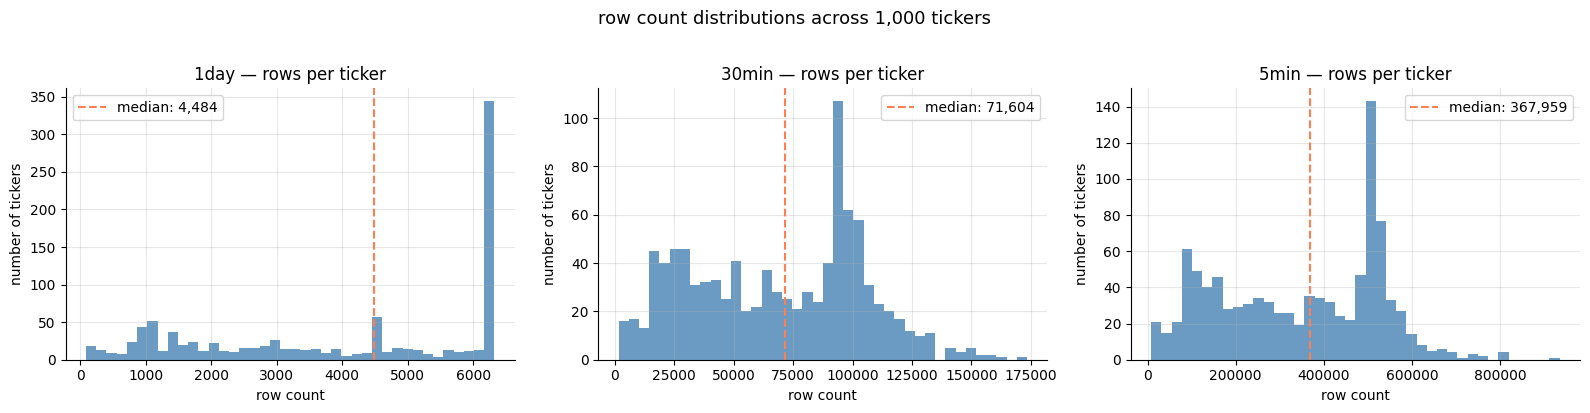

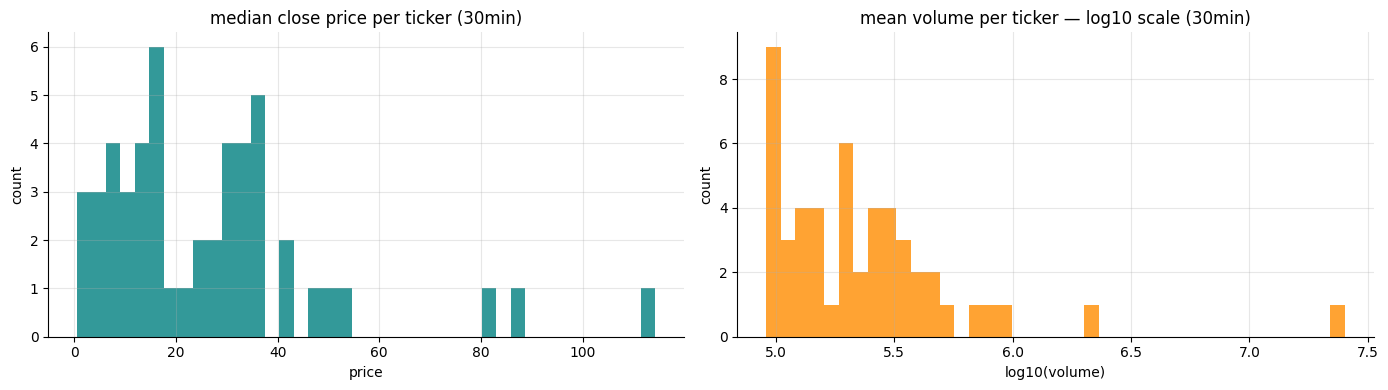

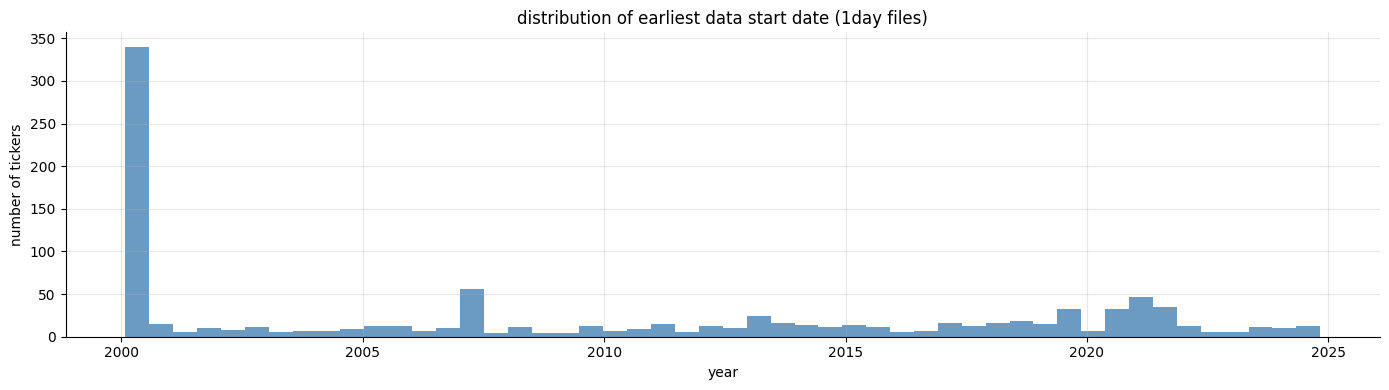

earliest start: 2000-01-03
latest start:   2024-10-21
all end at:      2025-02-26 (train cutoff)
most common bars/day: 14
regular hours 9:30-16:00 = 13 half-hour bars


In [ ]:
# --- visualizations: distributions and coverage ---

# 1. row count distribution per frequency
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, freq in zip(axes, FREQUENCIES):
    counts = []
    for ticker in TICKERS:
        path = DATA_DIR / f"{ticker}_{freq}.parquet"
        counts.append(pd.read_parquet(path, columns=["datetime"]).shape[0])
    ax.hist(counts, bins=40, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(f"{freq} — rows per ticker")
    ax.set_xlabel("row count")
    ax.set_ylabel("number of tickers")
    ax.axvline(np.median(counts), color="coral", linestyle="--", label=f"median: {np.median(counts):,.0f}")
    ax.legend()
plt.suptitle("row count distributions across 1,000 tickers", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 2. price and volume distributions (30min, sampled tickers)
close_vals = []
volume_vals = []
for ticker in sample_tickers:
    df = pd.read_parquet(DATA_DIR / f"{ticker}_30min.parquet")
    close_vals.append(df["close"].median())
    volume_vals.append(df["volume"].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(close_vals, bins=40, color="teal", edgecolor="none", alpha=0.8)
axes[0].set_title("median close price per ticker (30min)")
axes[0].set_xlabel("price")
axes[0].set_ylabel("count")

axes[1].hist(np.log10(np.array(volume_vals) + 1), bins=40, color="darkorange", edgecolor="none", alpha=0.8)
axes[1].set_title("mean volume per ticker — log10 scale (30min)")
axes[1].set_xlabel("log10(volume)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

# 3. date coverage: earliest start date per ticker (1day)
start_dates = []
for ticker in TICKERS:
    df = pd.read_parquet(DATA_DIR / f"{ticker}_1day.parquet", columns=["datetime"])
    start_dates.append(df["datetime"].min())

start_series = pd.Series(start_dates)
fig, ax = plt.subplots(figsize=(14, 4))
ax.hist(start_series.dt.year + start_series.dt.month / 12, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
ax.set_title("distribution of earliest data start date (1day files)")
ax.set_xlabel("year")
ax.set_ylabel("number of tickers")
plt.tight_layout()
plt.show()

print(f"earliest start: {start_series.min().date()}")
print(f"latest start:   {start_series.max().date()}")
print(f"all end at:      2025-02-26 (train cutoff)")

# 4. 30min bars per day — check for completeness
df_check = pd.read_parquet(DATA_DIR / f"{TICKERS[0]}_30min.parquet")
df_check = df_check[(df_check["datetime"].dt.time >= REGULAR_OPEN) & (df_check["datetime"].dt.time <= REGULAR_CLOSE)]
bars_per_day = df_check.groupby(df_check["datetime"].dt.date).size()

print(f"most common bars/day: {bars_per_day.mode().values[0]}")
print(f"regular hours 9:30-16:00 = 13 half-hour bars")

Each stock has OHLCV data (open, high, low, close, volume) at three frequencies. The ticker names are anonymized hashes — the same hash always refers to the same company across all frequencies.

In [ ]:
# pick a stock and look at its data across all three frequencies
sample_ticker = TICKERS[250]
print(f"ticker: {sample_ticker}")

for freq in FREQUENCIES:
    df = pd.read_parquet(DATA_DIR / f"{sample_ticker}_{freq}.parquet")
    print(f"\n{freq}: {df.shape[0]:,} rows, {df['datetime'].min().date()} to {df['datetime'].max().date()}")
    print(df.head(3).to_string(index=False))

ticker: 9F4F7D

1day: 6,325 rows, 2000-01-04 to 2025-02-26
  datetime   open   high    low  close    volume
2000-01-04 7.6858 7.7066 6.9984 7.0054 8235062.0
2000-01-05 7.0817 7.1789 6.7762 7.0609 5736097.0
2000-01-06 6.9498 7.0678 6.7068 6.8734 6566985.0

30min: 106,812 rows, 2000-01-03 to 2025-02-26
           datetime   open   high    low  close  volume
2000-01-03 09:30:00 7.6129 7.6233 7.2067 7.3317 1190967
2000-01-03 10:00:00 7.3317 7.5400 7.3317 7.5400  827286
2000-01-03 10:30:00 7.5400 7.6094 7.3733 7.3733  702160

5min: 541,250 rows, 2000-01-03 to 2025-02-26
           datetime   open   high    low  close  volume
2000-01-03 09:30:00 7.6129 7.6233 7.4983 7.6129  142232
2000-01-03 09:35:00 7.4983 7.4983 7.2206 7.2900  202545
2000-01-03 09:40:00 7.2900 7.4983 7.2067 7.3594  330374


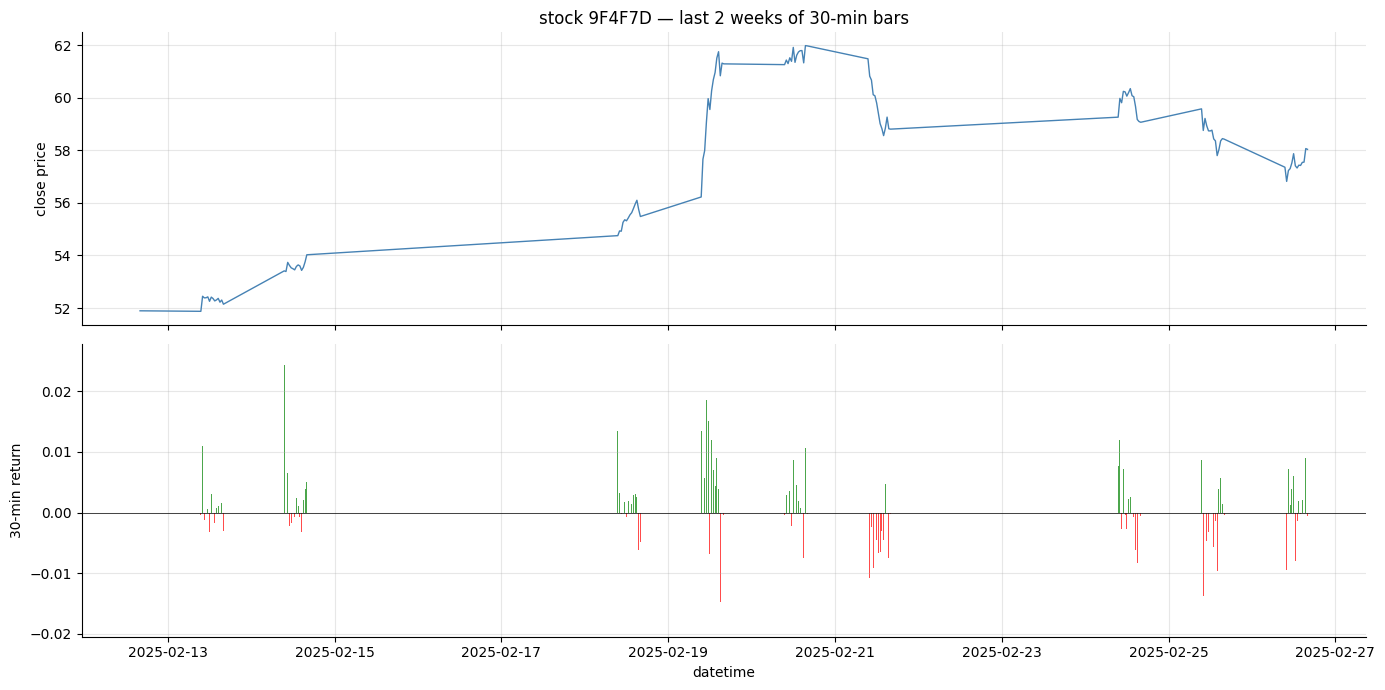

each bar is one 30-minute return. your model predicts these — which stocks go up, which go down.


In [ ]:
# visualize one stock's recent price history and 30-min returns
df_30 = pd.read_parquet(DATA_DIR / f"{sample_ticker}_30min.parquet")
df_30 = df_30[(df_30["datetime"].dt.time >= REGULAR_OPEN) & (df_30["datetime"].dt.time <= REGULAR_CLOSE)]
df_30 = df_30.sort_values("datetime")

recent = df_30[df_30["datetime"] >= df_30["datetime"].max() - pd.Timedelta(days=14)]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(recent["datetime"], recent["close"], color="steelblue", linewidth=1)
axes[0].set_ylabel("close price")
axes[0].set_title(f"stock {sample_ticker} — last 2 weeks of 30-min bars")

recent_return = recent["close"].pct_change()
colors = ["green" if r > 0 else "red" for r in recent_return]
axes[1].bar(recent["datetime"], recent_return, color=colors, width=0.01, alpha=0.7)
axes[1].set_ylabel("30-min return")
axes[1].set_xlabel("datetime")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

print("each bar is one 30-minute return. your model predicts these — which stocks go up, which go down.")

---
## 3. Build Features

Features are the X variables your model learns from. The raw data gives you price and volume. Your job is to transform those into signals that help predict the next 30 minutes.

**Important rule:** features at time t can only use data up to time t. No peeking at future data. We will verify this.

Below are examples at three levels. Use these as starting points, combine them, or build your own.

### Starter: Momentum and Volume Change

The simplest features — how much did the stock move in the last bar, and how much did volume change?

In [5]:
# compute starter features for all tickers from 30min data
# builds a dict: timestamp -> {ticker: {feature_name: value}}
#
# vectorized: groupby(date) + pct_change/shift compute all features in C-level
# pandas ops, then a single itertuples pass populates the nested dict.

features_by_timestamp = {}

for i, ticker in enumerate(TICKERS):
    df = pd.read_parquet(DATA_DIR / f"{ticker}_30min.parquet")
    df = df[(df["datetime"].dt.time >= REGULAR_OPEN) & (df["datetime"].dt.time <= REGULAR_CLOSE)]
    df = df.sort_values("datetime").reset_index(drop=True)

    # day-aware features — pct_change/shift within each trading day, NaN at day boundaries
    by_day = df.groupby(df["datetime"].dt.date, sort=False)
    momentum = by_day["close"].pct_change()
    vol_change = df["volume"] / by_day["volume"].shift(1)
    vol_change = vol_change.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    bar_range = (df["high"] - df["low"]) / df["close"]

    # drop the day-boundary rows where momentum is NaN (matches the original `continue`)
    feat = pd.DataFrame({
        "datetime": df["datetime"],
        "momentum": momentum,
        "volume_change": vol_change,
        "bar_range": bar_range,
    }).dropna(subset=["momentum"])

    # one C-level iteration to fill the nested dict
    for ts, mom, vc, br in feat.itertuples(index=False, name=None):
        bucket = features_by_timestamp.setdefault(ts, {})
        bucket[ticker] = {"momentum": mom, "volume_change": vc, "bar_range": br}

    if (i + 1) % 200 == 0:
        print(f"  processed {i + 1} / {len(TICKERS)} tickers")

print(f"\nfeatures computed for {len(features_by_timestamp)} timestamps")

  processed 200 / 1000 tickers
  processed 400 / 1000 tickers
  processed 600 / 1000 tickers
  processed 800 / 1000 tickers
  processed 1000 / 1000 tickers

features computed for 83176 timestamps


In [ ]:
# save features so you can skip the computation on kernel restart
with open(f"{project_root}/features_cache.pkl", "wb") as f:
    pickle.dump(features_by_timestamp, f)
print(f"saved to features_cache.pkl")

# to reload after kernel restart, uncomment and run this instead of the cell above:
# with open(f"{project_root}/features_cache.pkl", "rb") as f:
#     features_by_timestamp = pickle.load(f)
# print(f"loaded {len(features_by_timestamp)} timestamps from cache")

In [ ]:
!ls -la




total 2083220
drwxr-xr-x 1 root root       4096 Apr 30 01:33 .
drwxr-xr-x 1 root root       4096 Apr 29 21:54 ..
drwxr-xr-x 4 root root       4096 Apr 16 13:28 .config
drwxr-xr-x 3 root root       4096 Apr 30 00:54 data
drwx------ 5 root root       4096 Apr 30 00:54 drive
-rw-r--r-- 1 root root 2132986570 Apr 30 01:34 features_cache.pkl
drwxr-xr-x 1 root root       4096 Apr 16 13:28 sample_data
lrwxrwxrwx 1 root root         70 Apr 30 00:56 submission -> /content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026/submission
-rw------- 1 root root     194721 Apr 30 00:56 universe.json


In [ ]:
# !cp /content/features_cache.pkl /content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026/data/

---
## Load the features_cache.pkl

In [6]:
# to reload after kernel restart, uncomment and run this instead of the cell above:
with open(f"{project_root}/features_cache.pkl", "rb") as f:
     features_by_timestamp = pickle.load(f)
print(f"loaded {len(features_by_timestamp)} timestamps from cache")


loaded 83176 timestamps from cache


In [ ]:
# Quick inspection cell


# 1. top-level shape
print(f"type:           {type(features_by_timestamp).__name__}")
print(f"# timestamps:   {len(features_by_timestamp):,}")

# 2. timestamp range
all_ts = sorted(features_by_timestamp.keys())
print(f"first ts:       {all_ts[0]}")
print(f"last ts:        {all_ts[-1]}")

# 3. peek at one timestamp
sample_ts = all_ts[len(all_ts) // 2]   # pick something in the middle
cross_section = features_by_timestamp[sample_ts]
print(f"\nat {sample_ts}:")
print(f"  type:         {type(cross_section).__name__}")
print(f"  # tickers:    {len(cross_section):,}")

# 4. peek at one ticker within that timestamp
sample_ticker = next(iter(cross_section))
print(f"\n  ticker {sample_ticker}:")
print(f"    {cross_section[sample_ticker]}")

# 5. tickers-per-timestamp distribution (are all timestamps fully populated?)
import numpy as np
counts = np.array([len(v) for v in features_by_timestamp.values()])
print(f"\ntickers-per-timestamp:")
print(f"  min:    {counts.min()}")
print(f"  median: {int(np.median(counts))}")
print(f"  max:    {counts.max()}")

type:           dict
# timestamps:   83,176
first ts:       2000-01-03 10:00:00
last ts:        2025-02-26 16:00:00

at 2012-08-27 13:00:00:
  type:         dict
  # tickers:    603

  ticker 57E0D1:
    {'momentum': 0.0029664787896765965, 'volume_change': 1.608299986615268, 'bar_range': 0.004140786749482438}

tickers-per-timestamp:
  min:    1
  median: 597
  max:    997


### Observations


 83k 30-min timestamps × variable cross-section. A 25-year span (2000–2025) at 13 bars/day × ~252 days/year ≈ 82k bars  

Coverage is sparse in early years: min=1, median=597, max=997 is the key signal. This matters for training: a cross-sectional ranking model needs a wide cross-section to learn the relative-ranking pattern. Training on a 2002 timestamp with 50 tickers teaches it less than a 2024 timestamp with 990.


momentum = +0.0030 (+0.3% over 30 min) — typical magnitude
volume_change = 1.61 (61% more than prior bar) — moderately elevated
bar_range = 0.0041 (0.4% intraday range) — typical for liquid stocks

In [ ]:
# Quick filter/distribution check


counts = np.array([len(v) for v in features_by_timestamp.values()])
ts_list = sorted(features_by_timestamp.keys())

# how many timestamps clear common coverage thresholds?
for thresh in [100, 500, 800, 950]:
    n = (counts >= thresh).sum()
    print(f"timestamps with >={thresh} tickers: {n:,} ({100*n/len(counts):.1f}%)")

# coverage over time — pick first ts in each year, show its ticker count
import pandas as pd
df_cov = pd.Series(counts, index=pd.DatetimeIndex(ts_list))
yearly = df_cov.resample("YE").mean().round(0)
print("\navg tickers per timestamp by year:")
print(yearly.to_string())

timestamps with >=100 tickers: 82,017 (98.6%)
timestamps with >=500 tickers: 57,996 (69.7%)
timestamps with >=800 tickers: 18,371 (22.1%)
timestamps with >=950 tickers: 10,425 (12.5%)

avg tickers per timestamp by year:
2000-12-31    328.0
2001-12-31    351.0
2002-12-31    370.0
2003-12-31    389.0
2004-12-31    403.0
2005-12-31    422.0
2006-12-31    438.0
2007-12-31    493.0
2008-12-31    527.0
2009-12-31    540.0
2010-12-31    558.0
2011-12-31    580.0
2012-12-31    602.0
2013-12-31    641.0
2014-12-31    667.0
2015-12-31    692.0
2016-12-31    707.0
2017-12-31    731.0
2018-12-31    762.0
2019-12-31    804.0
2020-12-31    853.0
2021-12-31    934.0
2022-12-31    958.0
2023-12-31    970.0
2024-12-31    801.0
2025-12-31      1.0
Freq: YE-DEC


In [ ]:
# how many tickers have ANY bar in 2024 H2?
mask = pd.DatetimeIndex(sorted(features_by_timestamp.keys()))
late_2024 = [ts for ts in mask if pd.Timestamp("2024-07-01") <= ts < pd.Timestamp("2025-01-01")]
tickers_present = set()
for ts in late_2024:
    tickers_present.update(features_by_timestamp[ts].keys())
print(f"tickers with any data in 2024 H2: {len(tickers_present)}")

# count tickers present in each month of 2024

months = pd.date_range("2024-01-01", "2025-01-01", freq="MS")
for m_start in months[:-1]:
    m_end = m_start + pd.offsets.MonthEnd(0)
    bars = [ts for ts in features_by_timestamp if m_start <= ts <= m_end]
    tickers = set()
    for ts in bars:
        tickers.update(features_by_timestamp[ts].keys())
    print(f"{m_start.strftime('%Y-%m')}: {len(tickers)} unique tickers across {len(bars):,} bars")

# pick a ticker active in late 2024 — any one will do
sample = "57E0D1"

count_2024 = sum(1 for ts in features_by_timestamp
                 if ts.year == 2024 and sample in features_by_timestamp[ts])
expected = 252 * 13   # trading days × valid 30-min bars per day
print(f"{sample}: {count_2024:,} bars in 2024 (expected ~{expected:,})")
print(f"coverage: {count_2024/expected:.1%}")



tickers with any data in 2024 H2: 998
2024-01: 978 unique tickers across 273 bars
2024-02: 980 unique tickers across 247 bars
2024-03: 983 unique tickers across 260 bars
2024-04: 986 unique tickers across 273 bars
2024-05: 989 unique tickers across 286 bars
2024-06: 990 unique tickers across 260 bars
2024-07: 992 unique tickers across 286 bars
2024-08: 994 unique tickers across 286 bars
2024-09: 993 unique tickers across 247 bars
2024-10: 997 unique tickers across 286 bars
2024-11: 997 unique tickers across 273 bars
2024-12: 997 unique tickers across 260 bars
57E0D1: 3,276 bars in 2024 (expected ~3,276)
coverage: 100.0%


In [ ]:
# Ticker distribution
# coverage per ticker in 2024
from collections import Counter

ticker_counts_2024 = Counter()
total_bars_2024 = 0
for ts, cs in features_by_timestamp.items():
    if ts.year == 2024:
        total_bars_2024 += 1
        for t in cs:
            ticker_counts_2024[t] += 1

import numpy as np
covs = np.array([c / total_bars_2024 for c in ticker_counts_2024.values()])
for thresh in [1.0, 0.95, 0.80, 0.50]:
    n = (covs >= thresh).sum()
    print(f"tickers with >={thresh:.0%} bar coverage in 2024: {n}")


tickers with >=100% bar coverage in 2024: 0
tickers with >=95% bar coverage in 2024: 971
tickers with >=80% bar coverage in 2024: 978
tickers with >=50% bar coverage in 2024: 990


### Intermediate: Rolling Statistics

Compute features over a lookback window — rolling mean, rolling volatility. These capture trends and regimes that single-bar features miss.

In [ ]:
# example: rolling features for a single ticker
# loop over all tickers and add these to features_by_timestamp for your full pipeline

sample = pd.read_parquet(DATA_DIR / f"{TICKERS[0]}_30min.parquet")
sample = sample[(sample["datetime"].dt.time >= REGULAR_OPEN) & (sample["datetime"].dt.time <= REGULAR_CLOSE)]
sample = sample.sort_values("datetime")
sample["return"] = sample["close"].pct_change()

sample["rolling_mean_5"] = sample["return"].rolling(5).mean()
sample["rolling_std_5"] = sample["return"].rolling(5).std()
sample["rolling_volume_ratio"] = sample["volume"] / sample["volume"].rolling(5).mean()
sample["rolling_mean_13"] = sample["return"].rolling(13).mean()
sample["rolling_std_13"] = sample["return"].rolling(13).std()

print("rolling features for one ticker:")
print(sample[["datetime", "return", "rolling_mean_5", "rolling_std_5", "rolling_volume_ratio"]].dropna().tail(8).to_string(index=False))
print()
print("longer windows capture slower trends. shorter windows capture recent momentum.")

rolling features for one ticker:
           datetime    return  rolling_mean_5  rolling_std_5  rolling_volume_ratio
2025-02-26 12:30:00 -0.006689        0.001885       0.007258              0.771577
2025-02-26 13:00:00 -0.009834       -0.002612       0.005725              0.975120
2025-02-26 13:30:00 -0.007326       -0.004554       0.005232              1.308102
2025-02-26 14:00:00  0.003631       -0.003345       0.006415              1.357027
2025-02-26 14:30:00 -0.005408       -0.005125       0.005153              0.806782
2025-02-26 15:00:00  0.012017       -0.001384       0.009051              0.995671
2025-02-26 15:30:00  0.005966        0.001776       0.008068              1.621347
2025-02-26 16:00:00 -0.003954        0.002451       0.007212              1.650841

longer windows capture slower trends. shorter windows capture recent momentum.


#### Build full 8-feature long DataFrame

The dict-of-dicts above worked for 3 features but doesn't scale — each `{"momentum": x, ...}` dict has ~232 bytes of Python overhead, and adding more features makes that worse.

Switching to a **long-format DataFrame** (one row per `(datetime, ticker)`) cuts memory ~5× and is what LightGBM expects natively. This cell rebuilds features from scratch with **8 columns**:

- `momentum`, `volume_change`, `bar_range` (the starter features)
- `rolling_mean_5`, `rolling_std_5` — 5-bar (~2.5 hour) recent return mean and volatility
- `rolling_volume_ratio` — current volume vs. 5-bar mean volume
- `rolling_mean_13`, `rolling_std_13` — 13-bar (~one trading day) return mean and volatility

Day boundaries: the NaN at first-bar-of-day in `momentum` propagates into rolling windows. `min_periods` is set lower than the window size so we tolerate one or two NaN bars in each window without losing the whole feature.

In [7]:
print("computing 8-feature long DataFrame from parquet...")

parts = []
for i, ticker in enumerate(TICKERS):
    df = pd.read_parquet(DATA_DIR / f"{ticker}_30min.parquet")
    df = df[(df["datetime"].dt.time >= REGULAR_OPEN) &
            (df["datetime"].dt.time <= REGULAR_CLOSE)]
    df = df.sort_values("datetime").reset_index(drop=True)

    by_day = df.groupby(df["datetime"].dt.date, sort=False)

    # starter features
    momentum = by_day["close"].pct_change()
    vol_change = (df["volume"] / by_day["volume"].shift(1)) \
        .replace([np.inf, -np.inf], np.nan).fillna(0.0)
    bar_range = (df["high"] - df["low"]) / df["close"]

    # rolling features (windows cross day boundaries; min_periods absorbs day-start NaN)
    rolling_mean_5 = momentum.rolling(5, min_periods=3).mean()
    rolling_std_5  = momentum.rolling(5, min_periods=3).std()
    rolling_vol_mean = df["volume"].rolling(5, min_periods=3).mean()
    rolling_volume_ratio = (df["volume"] / rolling_vol_mean) \
        .replace([np.inf, -np.inf], np.nan)
    rolling_mean_13 = momentum.rolling(13, min_periods=10).mean()
    rolling_std_13  = momentum.rolling(13, min_periods=10).std()

    feat = pd.DataFrame({
        "datetime":             df["datetime"],
        "ticker":               ticker,
        "momentum":             momentum,
        "volume_change":        vol_change,
        "bar_range":            bar_range,
        "rolling_mean_5":       rolling_mean_5,
        "rolling_std_5":        rolling_std_5,
        "rolling_volume_ratio": rolling_volume_ratio,
        "rolling_mean_13":      rolling_mean_13,
        "rolling_std_13":       rolling_std_13,
    }).dropna(subset=["momentum"])

    parts.append(feat)

    if (i + 1) % 200 == 0:
        print(f"  processed {i + 1} / {len(TICKERS)} tickers")

print("concatenating...")
features_df = pd.concat(parts, ignore_index=True)
features_df["ticker"] = features_df["ticker"].astype("category")  # save memory
parts = None  # free memory

print(f"\nfeatures_df: {len(features_df):,} rows × {features_df.shape[1]} cols")
print(f"memory:      {features_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(features_df.head())

with open(f"{project_root}/features_long.pkl", "wb") as f:
    pickle.dump(features_df, f)
print("\nsaved to features_long.pkl")

computing 8-feature long DataFrame from parquet...
  processed 200 / 1000 tickers
  processed 400 / 1000 tickers
  processed 600 / 1000 tickers
  processed 800 / 1000 tickers
  processed 1000 / 1000 tickers
concatenating...

features_df: 51,446,654 rows × 10 cols
memory:      3.81 GB
             datetime  ticker  momentum  volume_change  bar_range  \
0 2000-01-03 10:00:00  57E0D1 -0.031355       1.399660   0.041618   
1 2000-01-03 10:30:00  57E0D1  0.001156       0.347509   0.025404   
2 2000-01-03 11:00:00  57E0D1  0.004619       1.171329   0.011494   
3 2000-01-03 11:30:00  57E0D1  0.014943       0.382090   0.019253   
4 2000-01-03 12:00:00  57E0D1  0.006795       3.484375   0.024747   

   rolling_mean_5  rolling_std_5  rolling_volume_ratio  rolling_mean_13  \
0             NaN            NaN                   NaN              NaN   
1             NaN            NaN              0.505598              NaN   
2       -0.008527       0.019846              0.659449              NaN   


### Advanced: Cross-Sectional Features and Multi-Timeframe

Compare each stock to the rest of the universe at each timestamp. Or use 5-minute data for finer-grained signals and aggregate up.

Ideas to explore:
- **Cross-sectional z-score:** how far is this stock's return from the universe mean, in standard deviations?
- **Sector-relative momentum:** cluster stocks by correlation, compare within clusters
- **5-min microstructure:** compute features from 5-min bars (intraday volatility, volume spikes) and attach to the 30-min grid
- **Time-of-day effects:** some times are systematically different — opening, closing, lunch
- **External libraries:** Prophet for trend decomposition, ta-lib for technical indicators, any ML library for learned features

In [ ]:
# example: cross-sectional z-score at one timestamp
sample_ts = sorted(features_by_timestamp.keys())[5000]
cross_section = features_by_timestamp[sample_ts]

mom_values = {t: cross_section[t]["momentum"] for t in cross_section}
mom_series = pd.Series(mom_values)

cs_mean = mom_series.mean()
cs_std = mom_series.std()
z_scores = (mom_series - cs_mean) / cs_std

print(f"timestamp: {sample_ts}")
print(f"stocks: {len(z_scores)}")
print(f"momentum range: {mom_series.min():.4f} to {mom_series.max():.4f}")
print(f"z-score range: {z_scores.min():.2f} to {z_scores.max():.2f}")
print(f"\ntop 5 (strongest relative to peers):")
print(z_scores.sort_values(ascending=False).head().to_string())
print(f"\nbottom 5:")
print(z_scores.sort_values().head().to_string())

timestamp: 2001-07-13 15:00:00
stocks: 357
momentum range: -0.0249 to 0.0261
z-score range: -4.06 to 4.88

top 5 (strongest relative to peers):
F11AD3    4.882567
3701D6    4.056121
1D214D    3.777902
F9B237    3.082262
B717DC    2.548192

bottom 5:
BAF77A   -4.057552
FE6F05   -3.481228
A5F84D   -3.311582
C25154   -3.216552
A0EC68   -2.817924


---
#### Build Sector Clusters

The data is anonymized — no sector labels — so we derive **pseudo-sectors** by clustering tickers on their daily-return correlations.

**Why daily, not 30-min:** sectors are about shared fundamental drivers (earnings, macro, sector-wide news) which show up cleanly at daily frequency. 30-min returns are dominated by microstructure noise that has nothing to do with sector membership.

**Why 2015–2025 (10 years):** enough observations for stable correlations (~2,500 days), recent enough to reflect current market structure, captures most tickers in the universe.

**What we save:** `submission/clusters.pkl` — a `{ticker: cluster_id}` dict with 20 clusters. Loaded by both the training cell and the submission's `prepare()`.

In [ ]:
import pickle
from sklearn.cluster import AgglomerativeClustering,  SpectralClustering

CLUSTER_START      = pd.Timestamp("2015-01-01")
CLUSTER_END        = pd.Timestamp("2025-01-01")
N_CLUSTERS         = 20
MIN_OBSERVATIONS   = 500   # tickers with fewer daily observations get cluster -1

# 1. Read 1day data and compute log returns
print(f"loading daily data {CLUSTER_START.date()} to {CLUSTER_END.date()}...")
daily_parts = []
for i, ticker in enumerate(TICKERS):
    df = pd.read_parquet(DATA_DIR / f"{ticker}_1day.parquet")
    df = df[(df["datetime"] >= CLUSTER_START) & (df["datetime"] < CLUSTER_END)]
    df = df.sort_values("datetime").reset_index(drop=True)
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    df = df[["datetime", "log_return"]].dropna()
    df["ticker"] = ticker
    daily_parts.append(df)
    if (i + 1) % 200 == 0:
        print(f"  {i + 1} / {len(TICKERS)}")

daily_df = pd.concat(daily_parts, ignore_index=True)
daily_parts = None

# 2. Pivot to date × ticker matrix
returns_wide = daily_df.pivot(index="datetime", columns="ticker", values="log_return")
print(f"\ndaily returns matrix: {returns_wide.shape[0]} days × {returns_wide.shape[1]} tickers")

# 3. Drop tickers with too few observations
obs_counts = returns_wide.notna().sum(axis=0)
kept_tickers = obs_counts[obs_counts >= MIN_OBSERVATIONS].index
returns_wide = returns_wide[kept_tickers]
print(f"kept {len(kept_tickers)} tickers with >= {MIN_OBSERVATIONS} observations")

# 4. Pairwise correlation (uses pairwise-complete observations)
# print("computing pairwise correlation matrix...")
# corr = returns_wide.corr(min_periods=100)
# corr = corr.fillna(0)   # any pair with too little overlap → uncorrelated

# 4a. Subtract market return (cross-sectional mean each day) — this is the
#     residual return after removing the common market factor.
print("removing market factor...")
market_return = returns_wide.mean(axis=1)            # ~equal-weighted market index
residual = returns_wide.sub(market_return, axis=0)   # ticker - market each day



# 4b. Pairwise correlation of residuals
print("computing residual correlation matrix...")
corr = residual.corr(min_periods=100)
corr = corr.fillna(0)

# 5. SPECTRAL CLUSTERING on the affinity matrix
#    Spectral methods do an eigendecomposition of the graph Laplacian, then
#    cluster the embedded points. They handle graph-like data (correlation
#    networks) much better than hierarchical when there's no clear distance
#    separation between clusters.
print(f"clustering into {N_CLUSTERS} sectors (spectral, normalized affinity)...")

# Affinity must be in [0, 1] for spectral. Clip negative correlations to 0 —
# negatively-correlated pairs become non-edges in the similarity graph.
affinity = np.maximum(corr.values, 0.0)
np.fill_diagonal(affinity, 1.0)  # self-similarity = 1

clusterer = SpectralClustering(
    n_clusters=N_CLUSTERS,
    affinity="precomputed",
    random_state=42,
    n_init=10,
    assign_labels="kmeans",
)
cluster_labels = clusterer.fit_predict(affinity)


# 5. Agglomerative Clustering: Convert to distance and cluster
# distance = 1.0 - corr.values   # range [0, 2]

# print(f"clustering into {N_CLUSTERS} sectors (hierarchical, average linkage)...")
# clusterer = AgglomerativeClustering(
#    n_clusters=N_CLUSTERS,
#    metric="precomputed",
#    linkage="average",
# )
# cluster_labels = clusterer.fit_predict(distance)

# 6. Build mapping (tickers excluded from clustering get -1)
cluster_map = dict(zip(corr.index.tolist(), cluster_labels.tolist()))
for ticker in TICKERS:
    if ticker not in cluster_map:
        cluster_map[ticker] = -1

# 7. Cluster size distribution
sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\ncluster sizes (in-cluster tickers):")
print(sizes.to_string())
unknown_n = sum(1 for v in cluster_map.values() if v == -1)
print(f"unknown (cluster -1):  {unknown_n}")

# 8. Save mapping for both training and submission
clusters_path = pathlib.Path(f"{project_root}/submission/clusters.pkl")
with open(clusters_path, "wb") as f:
    pickle.dump(cluster_map, f)
print(f"\nsaved cluster mapping to {clusters_path}")

loading daily data 2015-01-01 to 2025-01-01...
  200 / 1000
  400 / 1000
  600 / 1000
  800 / 1000
  1000 / 1000

daily returns matrix: 2560 days × 999 tickers
kept 959 tickers with >= 500 observations
removing market factor...
computing residual correlation matrix...
clustering into 20 sectors (spectral, normalized affinity)...

cluster sizes (in-cluster tickers):
0      64
1      21
2      34
3      15
4     108
5      27
6      72
7      25
8      34
9      13
10     24
11     23
12     33
13     40
14     92
15     61
16     43
17     11
18     15
19    204
unknown (cluster -1):  41

saved cluster mapping to /content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026/submission/clusters.pkl


#### Build 4 microstructure features from 5-min data

5-min bars describe what happened *inside* each 30-min bar. Each 30-min window contains 6 underlying 5-min bars (e.g., the 10:00 30-min bar contains 5-min bars at 10:00, 10:05, 10:10, 10:15, 10:20, 10:25).

We aggregate these 6 bars into 4 features per 30-min window, then merge with `features_long.pkl` (the existing 8-feature DataFrame). Each feature describes the **same 30-min bar** the existing features describe, just at finer granularity.

| Feature | Formula | Captures |
|---|---|---|
| `intrabar_std` | std of 6 five-min returns | Within-bar volatility (different from `bar_range` = high − low) |
| `close_position` | (close − low) / (high − low) | Did the bar finish near its high or low |
| `volume_concentration` | max 5-min volume / total volume | Spike vs. steady volume distribution |
| `tail_strength` | return of the last 5-min bar | Did momentum accelerate at the bar's end |

**Memory note:** 5-min data is 6× larger than 30-min, but we aggregate per ticker → throw away raw rows → keep only 4 numbers per 30-min window. Final pkl is similar size to `features_long.pkl`. Build takes ~10 minutes on local SSD.

**Saves to `features_5min.pkl`** — kept separate from `features_long.pkl` so you can iterate on 5-min features without rebuilding the base DataFrame.

In [8]:
print("computing 4 5-min microstructure features per 30-min window...")

parts_5min = []
for i, ticker in enumerate(TICKERS):
    df_5 = pd.read_parquet(DATA_DIR / f"{ticker}_5min.parquet")
    df_5 = df_5[(df_5["datetime"].dt.time >= REGULAR_OPEN) &
                (df_5["datetime"].dt.time <= REGULAR_CLOSE)]
    df_5 = df_5.sort_values("datetime").reset_index(drop=True)

    # 5-min returns within day (NaN at day boundaries — won't propagate since we
    # aggregate to 30-min windows that are entirely within a day)
    by_day = df_5.groupby(df_5["datetime"].dt.date, sort=False)
    df_5["ret"] = by_day["close"].pct_change()

    # Each 5-min bar belongs to the 30-min window that floors its timestamp.
    # 10:00, 10:05, ..., 10:25 → all floor to 10:00.
    df_5["window"] = df_5["datetime"].dt.floor("30min")

    agg = df_5.groupby("window", sort=True).agg(
        intrabar_std=("ret", "std"),
        high_30=("high", "max"),
        low_30=("low", "min"),
        close_30=("close", "last"),
        vol_max=("volume", "max"),
        vol_sum=("volume", "sum"),
        tail_strength=("ret", "last"),
    )
    agg["close_position"] = (agg["close_30"] - agg["low_30"]) / (agg["high_30"] - agg["low_30"])
    agg["volume_concentration"] = agg["vol_max"] / agg["vol_sum"]

    feat = agg[["intrabar_std", "close_position", "volume_concentration", "tail_strength"]] \
        .reset_index().rename(columns={"window": "datetime"})
    feat["ticker"] = ticker
    parts_5min.append(feat)

    if (i + 1) % 200 == 0:
        print(f"  processed {i + 1} / {len(TICKERS)} tickers")

print("concatenating...")
features_5min_df = pd.concat(parts_5min, ignore_index=True)
features_5min_df["ticker"] = features_5min_df["ticker"].astype("category")
parts_5min = None  # free memory

print(f"\nfeatures_5min_df: {len(features_5min_df):,} rows × {features_5min_df.shape[1]} cols")
print(f"memory:           {features_5min_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(features_5min_df.head())

with open(f"{project_root}/features_5min.pkl", "wb") as f:
    pickle.dump(features_5min_df, f)
print("\nsaved to features_5min.pkl")


computing 4 5-min microstructure features per 30-min window...
  processed 200 / 1000 tickers
  processed 400 / 1000 tickers
  processed 600 / 1000 tickers
  processed 800 / 1000 tickers
  processed 1000 / 1000 tickers
concatenating...

features_5min_df: 55,319,808 rows × 6 cols
memory:           2.32 GB
             datetime  intrabar_std  close_position  volume_concentration  \
0 2000-01-03 09:30:00      0.011299        0.250000              0.255102   
1 2000-01-03 10:00:00      0.010681        0.194444              0.269745   
2 2000-01-03 10:30:00      0.007127        0.318182              0.321678   
3 2000-01-03 11:00:00      0.003073        0.900000              0.522388   
4 2000-01-03 11:30:00      0.005455        1.000000              0.398438   

   tail_strength  ticker  
0       0.010181  57E0D1  
1      -0.002307  57E0D1  
2       0.008149  57E0D1  
3       0.005780  57E0D1  
4       0.001134  57E0D1  

saved to features_5min.pkl


---
#### Build features_extras.pkl
Integrate 5 additional features from Jenifer and Justin's code

In [7]:
print("computing 5 extra features per 30-min bar...")

parts_extras = []
for i, ticker in enumerate(TICKERS):
    # --- 30-min bar features ---
    df = pd.read_parquet(DATA_DIR / f"{ticker}_30min.parquet")
    df = df[(df["datetime"].dt.time >= REGULAR_OPEN) &
            (df["datetime"].dt.time <= REGULAR_CLOSE)]
    df = df.sort_values("datetime").reset_index(drop=True)

    # Time-of-day (390 minutes = 6.5 hour session)
    minutes_in_day = df["datetime"].dt.hour * 60 + df["datetime"].dt.minute
    minutes_from_open = (minutes_in_day - 9 * 60 - 30).clip(lower=0)
    minutes_to_close  = (16 * 60 - minutes_in_day).clip(lower=0)

    # Dollar volume (economic significance — $10 stock × 1M vol ≠ $200 stock × 1M vol)
    dollar_volume = df["close"] * df["volume"]

    # Intraday VWAP (cumulative within day)
    df["date"] = df["datetime"].dt.date
    cum_dv  = dollar_volume.groupby(df["date"]).cumsum()
    cum_vol = df["volume"].groupby(df["date"]).cumsum()
    vwap = cum_dv / cum_vol
    vwap_distance = (df["close"] - vwap) / vwap

    # Gap return — read daily file, compute (today_open - prev_close) / prev_close
    df_d = pd.read_parquet(DATA_DIR / f"{ticker}_1day.parquet")
    df_d = df_d.sort_values("datetime").reset_index(drop=True)
    df_d["prev_close"] = df_d["close"].shift(1)
    df_d["gap_return"] = (df_d["open"] - df_d["prev_close"]) / df_d["prev_close"]
    df_d["date"] = df_d["datetime"].dt.date
    # Map daily gap to all 30-min bars in that day
    df["gap_return"] = df["date"].map(dict(zip(df_d["date"], df_d["gap_return"])))

    out = pd.DataFrame({
        "datetime":           df["datetime"],
        "ticker":             ticker,
        "minutes_from_open":  minutes_from_open.astype("int16"),
        "minutes_to_close":   minutes_to_close.astype("int16"),
        "dollar_volume":      dollar_volume.astype("float32"),
        "vwap_distance":      vwap_distance.astype("float32"),
        "gap_return":         df["gap_return"].astype("float32"),
    })
    parts_extras.append(out)

    if (i + 1) % 200 == 0:
        print(f"  processed {i + 1} / {len(TICKERS)} tickers")

print("concatenating...")
features_extras_df = pd.concat(parts_extras, ignore_index=True)
features_extras_df["ticker"] = features_extras_df["ticker"].astype("category")
parts_extras = None

print(f"\nfeatures_extras_df: {len(features_extras_df):,} rows × {features_extras_df.shape[1]} cols")
print(f"memory: {features_extras_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(features_extras_df.head())

with open(f"{project_root}/features_extras.pkl", "wb") as f:
    pickle.dump(features_extras_df, f)
print("\nsaved to features_extras.pkl")


computing 5 extra features per 30-min bar...
  processed 200 / 1000 tickers
  processed 400 / 1000 tickers
  processed 600 / 1000 tickers
  processed 800 / 1000 tickers
  processed 1000 / 1000 tickers
concatenating...

features_extras_df: 55,442,504 rows × 7 cols
memory: 1.44 GB
             datetime  ticker  minutes_from_open  minutes_to_close  \
0 2000-01-03 09:30:00  57E0D1                  0               390   
1 2000-01-03 10:00:00  57E0D1                 30               360   
2 2000-01-03 10:30:00  57E0D1                 60               330   
3 2000-01-03 11:00:00  57E0D1                 90               300   
4 2000-01-03 11:30:00  57E0D1                120               270   

   dollar_volume  vwap_distance  gap_return  
0    2701295.750       0.000000         NaN  
1    3662345.750      -0.013310         NaN  
2    1274169.625      -0.010139         NaN  
3    1499365.250      -0.004653         NaN  
4     581452.250       0.009608         NaN  

saved to features_extr

In [9]:
!ls -lh "{project_root}/features_extras.pkl"


-rw------- 1 root root 1.4G May  3 00:53 /content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026/features_extras.pkl


In [17]:
del features_extras_df
gc.collect()

60

---
## 4. Evaluate Locally

Before you submit, test whether your features have signal. Split your training data into a train and validation period, generate predictions on the validation period, and compute Spearman IC — the same metric we use for scoring.

A consistently positive IC on validation data means your features are finding real patterns.

validation period: 2024-11-28 16:00:00 to 2025-02-26 16:00:00
validation timestamps: 794

local validation (708 timestamps):
  mean IC:  -0.0478
  std IC:   0.1253
  pct > 0:  33.6%


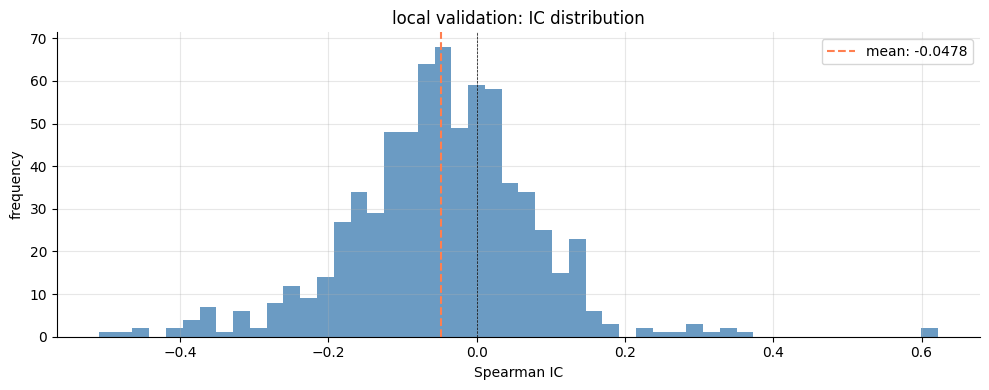


mean IC near zero = no predictive power. try more features or a different approach.


In [ ]:
from scipy.stats import spearmanr

# use the last 3 months of training data as a validation set
all_ts = sorted(features_by_timestamp.keys())
val_cutoff = all_ts[-1] - pd.Timedelta(days=90)
val_timestamps = [ts for ts in all_ts if ts >= val_cutoff]
print(f"validation period: {val_timestamps[0]} to {val_timestamps[-1]}")
print(f"validation timestamps: {len(val_timestamps)}")

ic_values = []
# speedup
ts_to_idx = {ts: i for i, ts in enumerate(all_ts)}   # build once before the loop
for ts in val_timestamps:
    if ts not in features_by_timestamp:
        continue
    cross_section = features_by_timestamp[ts]
    # predicted score = momentum (replace with your model's output)
    predictions = {t: cross_section[t]["momentum"] for t in cross_section}
    # find the next timestamp for the realized return
    #ts_idx = all_ts.index(ts)
    # speedup
    ts_idx = ts_to_idx[ts]
    if ts_idx + 1 >= len(all_ts):
        continue
    next_ts = all_ts[ts_idx + 1]
    if next_ts.date() != ts.date():
        continue
    if next_ts not in features_by_timestamp:
        continue
    realized = {t: features_by_timestamp[next_ts][t]["momentum"]
                for t in features_by_timestamp[next_ts]
                if t in predictions}
    common = set(predictions.keys()) & set(realized.keys())
    if len(common) < 100:
        continue
    pred_arr = np.array([predictions[t] for t in common])
    real_arr = np.array([realized[t] for t in common])
    ic, _ = spearmanr(pred_arr, real_arr)
    if not np.isnan(ic):
        ic_values.append(ic)

ic_array = np.array(ic_values)
print(f"\nlocal validation ({len(ic_values)} timestamps):")
print(f"  mean IC:  {ic_array.mean():.4f}")
print(f"  std IC:   {ic_array.std():.4f}")
print(f"  pct > 0:  {(ic_array > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ic_array, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(ic_array.mean(), color="coral", linestyle="--", label=f"mean: {ic_array.mean():.4f}")
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_xlabel("Spearman IC")
ax.set_ylabel("frequency")
ax.set_title("local validation: IC distribution")
ax.legend()
plt.tight_layout()
plt.show()

print("\nmean IC near zero = no predictive power. try more features or a different approach.")

---
#### 4.1 LightGBM

The baseline (raw `momentum`) gave a *negative* IC — short-term mean reversion. A trained model can pick up the sign automatically and combine all three features. This cell:

1. Builds a flat training matrix: one row per `(timestamp, ticker)` with the next bar's return as the target.
2. Splits time-wise (no random shuffling — that would leak future info).
3. Trains a LightGBM regressor with early stopping.
4. Reports validation IC and saves weights to `submission/weights.pkl`.

The submission `model.py` will load these weights at scoring time.

In [ ]:
import pickle
import lightgbm as lgb
from scipy.stats import spearmanr

FEATURES = ["momentum", "volume_change", "bar_range"]

# 1. Build flat training matrix from features_by_timestamp.
#    Memory-aware: preallocate numpy arrays instead of list-of-tuples.
all_ts = sorted(features_by_timestamp.keys())
ts_to_idx = {ts: i for i, ts in enumerate(all_ts)}

n_max = sum(len(features_by_timestamp[ts]) for ts in all_ts)
ts_arr     = np.empty(n_max, dtype="datetime64[ns]")
ticker_arr = np.empty(n_max, dtype=object)
mom_arr    = np.empty(n_max, dtype=np.float64)
vol_arr    = np.empty(n_max, dtype=np.float64)
range_arr  = np.empty(n_max, dtype=np.float64)
target_arr = np.empty(n_max, dtype=np.float64)

idx = 0
for i, ts in enumerate(all_ts):
    if i + 1 >= len(all_ts):
        break
    next_ts = all_ts[i + 1]
    if next_ts.date() != ts.date():
        continue
    cs = features_by_timestamp[ts]
    next_cs = features_by_timestamp.get(next_ts, {})
    for ticker, f in cs.items():
        nxt = next_cs.get(ticker)
        if nxt is None:
            continue
        ts_arr[idx]     = ts
        ticker_arr[idx] = ticker
        mom_arr[idx]    = f["momentum"]
        vol_arr[idx]    = f["volume_change"]
        range_arr[idx]  = f["bar_range"]
        target_arr[idx] = nxt["momentum"]
        idx += 1

df = pd.DataFrame({
    "ts":            ts_arr[:idx],
    "ticker":        ticker_arr[:idx],
    "momentum":      mom_arr[:idx],
    "volume_change": vol_arr[:idx],
    "bar_range":     range_arr[:idx],
    "target":        target_arr[:idx],
})
print(f"training rows: {len(df):,}  ({df['ts'].min()} to {df['ts'].max()})")

# 2. Time-based split: train on data ending 2023-09-30, validate on 2023-Q4
# TRAIN_END = pd.Timestamp("2023-10-01")
# VAL_END   = pd.Timestamp("2024-01-01")
val_cutoff = all_ts[-1] - pd.Timedelta(days=90)
val_timestamps = [ts for ts in all_ts if ts >= val_cutoff]
#train = df[df["ts"] < TRAIN_END]
train = df[df["ts"] < val_cutoff]
#val   = df[(df["ts"] >= TRAIN_END) & (df["ts"] < VAL_END)]
val   = df[df["ts"] >= val_cutoff]
print(f"train rows: {len(train):,}, val rows: {len(val):,}")

# 3. Train LightGBM regressor with early stopping
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=500,   # large min_child_samples — lots of data, prevents overfitting noise
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
model.fit(
    train[FEATURES], train["target"],
    eval_set=[(val[FEATURES], val["target"])],
    eval_metric="mse",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)],
)

# 4. Evaluate per-timestamp IC on validation
val = val.copy()
val["pred"] = model.predict(val[FEATURES])
ic_per_ts = (
    val.groupby("ts")
    .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
    .dropna()
)
print(f"\nLightGBM validation IC over {len(ic_per_ts)} timestamps:")
print(f"  mean IC:  {ic_per_ts.mean():+.4f}")
print(f"  std IC:   {ic_per_ts.std():.4f}")
print(f"  pct > 0:  {(ic_per_ts > 0).mean():.1%}")
print(f"  (baseline raw-momentum IC was -0.0478 on a different window)")

# 5. Save weights for the submission
weights_path = pathlib.Path(f"{project_root}/submission/weights.pkl")
with open(weights_path, "wb") as f:
    pickle.dump(model, f)
print(f"\nsaved trained model to {weights_path}")

training rows: 47,374,898  (2000-01-03 10:00:00 to 2025-02-26 15:30:00)
train rows: 46,678,270, val rows: 696,628
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's l2: 5.16542e-05

LightGBM validation IC over 708 timestamps:
  mean IC:  +0.0412
  std IC:   0.1120
  pct > 0:  65.3%
  (baseline raw-momentum IC was -0.0478 on a different window)

saved trained model to /content/drive/MyDrive/Four-Sigma/four-sigma-hackathon-2026/submission/weights.pkl


/tmp/ipykernel_53991/786237408.py:88: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)


#### 4.2 LightGBM with rolling statistics

In [ ]:
import pickle
import lightgbm as lgb
from scipy.stats import spearmanr

FEATURES = [
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_std_5", "rolling_volume_ratio",
    "rolling_mean_13", "rolling_std_13",
]

# load the long DataFrame (already in memory if you just built it)
if "features_df" not in globals():
    with open(f"{project_root}/features_long.pkl", "rb") as f:
        features_df = pickle.load(f)
print(f"features_df: {len(features_df):,} rows")

# 1. compute target = next bar's momentum within (ticker, day)
features_df = features_df.sort_values(["ticker", "datetime"]).reset_index(drop=True)
features_df["date"] = features_df["datetime"].dt.date
features_df["target"] = (
    features_df.groupby(["ticker", "date"], observed=True, sort=False)["momentum"].shift(-1)
)
df_train = features_df.dropna(subset=["target"])
print(f"after target alignment: {len(df_train):,} rows")

# 2. time-based split — train on history, validate on last 90 days (matches local-eval cell)
val_cutoff = df_train["datetime"].max() - pd.Timedelta(days=90)
train = df_train[df_train["datetime"] < val_cutoff]
val   = df_train[df_train["datetime"] >= val_cutoff]
print(f"train: {len(train):,}, val: {len(val):,}")

# 3. train LightGBM regressor with early stopping
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=500,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
model.fit(
    train[FEATURES], train["target"],
    eval_set=[(val[FEATURES], val["target"])],
    eval_metric="mse",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)],
)

# 4. evaluate per-timestamp IC on validation
val = val.copy()
val["pred"] = model.predict(val[FEATURES])
ic_per_ts = (
    val.groupby("datetime")[["pred", "target"]]
    .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
    .dropna()
)
print(f"\nLightGBM (8 features) validation IC over {len(ic_per_ts)} timestamps:")
print(f"  mean IC:  {ic_per_ts.mean():+.4f}")
print(f"  std IC:   {ic_per_ts.std():.4f}")
print(f"  pct > 0:  {(ic_per_ts > 0).mean():.1%}")
print(f"  (3-feature model on same window: +0.0412)")
print(f"  (flipped-momentum baseline:      +0.0478)")

# 5. feature importance — what is the model actually using?
imp = pd.Series(
    model.booster_.feature_importance(importance_type="gain"),
    index=FEATURES,
).sort_values(ascending=False)
print("\nfeature importance (gain):")
print(imp.to_string())

# 6. save weights for the submission
weights_path = pathlib.Path(f"{project_root}/submission/weights.pkl")
with open(weights_path, "wb") as f:
    pickle.dump(model, f)
print(f"\nsaved trained model to {weights_path}")

features_df: 51,446,654 rows
after target alignment: 47,452,271 rows
train: 46,754,588, val: 697,683
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[35]	valid_0's l2: 5.1761e-05

LightGBM (8 features) validation IC over 708 timestamps:
  mean IC:  +0.0441
  std IC:   0.1240
  pct > 0:  64.4%
  (3-feature model on same window: +0.0412)
  (flipped-momentum baseline:      +0.0478)

feature importance (gain):
momentum                17.095258
bar_range               16.007114
rolling_volume_ratio     9.016771
volume_change            5.817482
rolling_mean_5           5.552519
rolling_std_13           5.380081
rolling_mean_13          5.149397
rolling_std_5            4.794137

saved trained model to submission/weights.pkl


#### 4.3 LightGBM + Base features + rolling stats + z-scores

In [ ]:
import pickle
import lightgbm as lgb
from scipy.stats import spearmanr

FEATURES = [
    # per-ticker (single-stock) features
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_std_5", "rolling_volume_ratio",
    "rolling_mean_13", "rolling_std_13",
    # cross-sectional features (this stock vs. the universe at the same timestamp)
    "momentum_z", "momentum_rank", "bar_range_z", "volume_change_z",
    "rolling_mean_5_z", "rolling_mean_13_z", "rolling_volume_ratio_z",
]

# Restrict to recent regime — fits RAM, avoids stale market regimes, and uses bars
# with denser cross-sections (2020+ has ~850+ tickers/bar vs. ~330 in 2000).
TRAIN_START = pd.Timestamp("2020-01-01")

# load the long DataFrame
if "features_df" not in globals():
    with open(f"{project_root}/features_long.pkl", "rb") as f:
        features_df = pickle.load(f)
print(f"features_df: {len(features_df):,} rows")

features_df = features_df[features_df["datetime"] >= TRAIN_START].reset_index(drop=True)
print(f"features_df (>= {TRAIN_START.date()}): {len(features_df):,} rows")

# 1. CROSS-SECTIONAL FEATURES — compare each ticker against its peers at every timestamp.
print("computing cross-sectional features...")
ts_groups = features_df.groupby("datetime", observed=True, sort=False)
for col in [
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_mean_13", "rolling_volume_ratio",
]:
    cs_mean = ts_groups[col].transform("mean")
    cs_std  = ts_groups[col].transform("std")
    features_df[f"{col}_z"] = (features_df[col] - cs_mean) / cs_std
features_df["momentum_rank"] = ts_groups["momentum"].rank(pct=True)
print(f"  added 7 cross-sectional features")

# 2. target = next bar's momentum within (ticker, day)
features_df = features_df.sort_values(["ticker", "datetime"]).reset_index(drop=True)
features_df["date"] = features_df["datetime"].dt.date
features_df["target"] = (
    features_df.groupby(["ticker", "date"], observed=True, sort=False)["momentum"].shift(-1)
)
df_train = features_df.dropna(subset=["target"])
print(f"after target alignment: {len(df_train):,} rows")

# 3. time-based split — train on history, validate on last 90 days
val_cutoff = df_train["datetime"].max() - pd.Timedelta(days=90)
train = df_train[df_train["datetime"] < val_cutoff]
val   = df_train[df_train["datetime"] >= val_cutoff]
print(f"train: {len(train):,}, val: {len(val):,}")

# 4. train LightGBM regressor with early stopping
#    LightGBM handles NaN in features natively — early bars (where rolling/cs features
#    are NaN) are routed to the model's "missing direction" in each split.
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=500,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
model.fit(
    train[FEATURES], train["target"],
    eval_set=[(val[FEATURES], val["target"])],
    eval_metric="mse",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)],
)

# 5. evaluate per-timestamp IC on validation
val = val.copy()
val["pred"] = model.predict(val[FEATURES])
ic_per_ts = (
    val.groupby("datetime")[["pred", "target"]]
    .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
    .dropna()
)
print(f"\nLightGBM ({len(FEATURES)} features) validation IC over {len(ic_per_ts)} timestamps:")
print(f"  mean IC:  {ic_per_ts.mean():+.4f}")
print(f"  std IC:   {ic_per_ts.std():.4f}")
print(f"  pct > 0:  {(ic_per_ts > 0).mean():.1%}")
print(f"  (8-feature model on same window:  +0.0441)")
print(f"  (3-feature model on same window:  +0.0412)")
print(f"  (flipped-momentum baseline:       +0.0478)")

# 6. feature importance — see whether cross-sectional features are pulling weight
imp = pd.Series(
    model.booster_.feature_importance(importance_type="gain"),
    index=FEATURES,
).sort_values(ascending=False)
print("\nfeature importance (gain):")
print(imp.to_string())

# 7. save weights for the submission
weights_path = pathlib.Path(f"{project_root}/submission/weights.pkl")
with open(weights_path, "wb") as f:
    pickle.dump(model, f)
print(f"\nsaved trained model to {weights_path}")

features_df: 51,446,654 rows
features_df (>= 2020-01-01): 15,701,897 rows
computing cross-sectional features...
  added 7 cross-sectional features
after target alignment: 14,489,991 rows
train: 13,792,308, val: 697,683
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[104]	valid_0's l2: 5.17286e-05

LightGBM (15 features) validation IC over 708 timestamps:
  mean IC:  +0.0465
  std IC:   0.1139
  pct > 0:  65.7%
  (8-feature model on same window:  +0.0441)
  (3-feature model on same window:  +0.0412)
  (flipped-momentum baseline:       +0.0478)

feature importance (gain):
rolling_volume_ratio      5.112828
rolling_volume_ratio_z    4.578304
momentum_rank             4.167870
momentum                  3.969881
rolling_mean_13           3.363417
momentum_z                3.157073
rolling_mean_5            2.750222
volume_change             2.688184
bar_range                 2.505053
volume_change_z           2.045423
rolling_std_13          

#### 4.4 LightGBM + base features + rolling + z-scores + clusters

In [ ]:
import pickle
import lightgbm as lgb
from scipy.stats import spearmanr

FEATURES = [
    # per-ticker features
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_std_5", "rolling_volume_ratio",
    "rolling_mean_13", "rolling_std_13",
    # cross-sectional features (vs. universe)
    "momentum_z", "momentum_rank", "bar_range_z", "volume_change_z",
    "rolling_mean_5_z", "rolling_mean_13_z", "rolling_volume_ratio_z",
    # sector-relative features (vs. cluster)
    "momentum_relative_to_sector", "momentum_sector_z",
]

TRAIN_START = pd.Timestamp("2020-01-01")

# load the long DataFrame
if "features_df" not in globals():
    with open(f"{project_root}/features_long.pkl", "rb") as f:
        features_df = pickle.load(f)
print(f"features_df (full): {len(features_df):,} rows")

features_df = features_df[features_df["datetime"] >= TRAIN_START].reset_index(drop=True)
print(f"features_df (>= {TRAIN_START.date()}): {len(features_df):,} rows")

# load sector cluster mapping
with open(f"{project_root}/submission/clusters.pkl", "rb") as f:
    cluster_map = pickle.load(f)
features_df["cluster"] = features_df["ticker"].astype(str).map(cluster_map).astype("int16")
print(f"sector mapping loaded: {features_df['cluster'].nunique()} unique clusters")

# 1. CROSS-SECTIONAL FEATURES (universe-relative)
print("computing cross-sectional features...")
ts_groups = features_df.groupby("datetime", observed=True, sort=False)
for col in [
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_mean_13", "rolling_volume_ratio",
]:
    cs_mean = ts_groups[col].transform("mean")
    cs_std  = ts_groups[col].transform("std")
    features_df[f"{col}_z"] = (features_df[col] - cs_mean) / cs_std
features_df["momentum_rank"] = ts_groups["momentum"].rank(pct=True)

# 2. SECTOR-RELATIVE FEATURES — momentum vs. sector mean and z-score within sector
print("computing sector-relative features...")
sector_groups = features_df.groupby(["datetime", "cluster"], observed=True, sort=False)
sector_mean = sector_groups["momentum"].transform("mean")
sector_std  = sector_groups["momentum"].transform("std")
features_df["momentum_relative_to_sector"] = features_df["momentum"] - sector_mean
features_df["momentum_sector_z"] = (features_df["momentum"] - sector_mean) / sector_std

# 3. target = next bar's momentum within (ticker, day)
features_df = features_df.sort_values(["ticker", "datetime"]).reset_index(drop=True)
features_df["date"] = features_df["datetime"].dt.date
features_df["target"] = (
    features_df.groupby(["ticker", "date"], observed=True, sort=False)["momentum"].shift(-1)
)
df_train = features_df.dropna(subset=["target"])
print(f"after target alignment: {len(df_train):,} rows")

# 4. time-based split — train on history, validate on last 90 days
val_cutoff = df_train["datetime"].max() - pd.Timedelta(days=90)
train = df_train[df_train["datetime"] < val_cutoff]
val   = df_train[df_train["datetime"] >= val_cutoff]
print(f"train: {len(train):,}, val: {len(val):,}")

# 5. train LightGBM regressor with early stopping
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=500,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
model.fit(
    train[FEATURES], train["target"],
    eval_set=[(val[FEATURES], val["target"])],
    eval_metric="mse",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)],
)

# 6. evaluate per-timestamp IC on validation
val = val.copy()
val["pred"] = model.predict(val[FEATURES])
ic_per_ts = (
    val.groupby("datetime")[["pred", "target"]]
    .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
    .dropna()
)
print(f"\nLightGBM ({len(FEATURES)} features, train >= {TRAIN_START.date()}) validation IC over {len(ic_per_ts)} timestamps:")
print(f"  mean IC:  {ic_per_ts.mean():+.4f}")
print(f"  std IC:   {ic_per_ts.std():.4f}")
print(f"  pct > 0:  {(ic_per_ts > 0).mean():.1%}")
print(f"  (15-feature model on same window: +0.0465)")
print(f"  (8-feature model on same window:  +0.0441)")
print(f"  (flipped-momentum baseline:       +0.0478)")

# 7. feature importance
imp = pd.Series(
    model.booster_.feature_importance(importance_type="gain"),
    index=FEATURES,
).sort_values(ascending=False)
print("\nfeature importance (gain):")
print(imp.to_string())

# 8. save weights for the submission
weights_path = pathlib.Path(f"{project_root}/submission/weights.pkl")
with open(weights_path, "wb") as f:
    pickle.dump(model, f)
print(f"\nsaved trained model to {weights_path}")

features_df (full): 15,701,897 rows
features_df (>= 2020-01-01): 15,701,897 rows
sector mapping loaded: 21 unique clusters
computing cross-sectional features...
computing sector-relative features...
after target alignment: 14,489,991 rows
train: 13,792,308, val: 697,683
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[57]	valid_0's l2: 5.17136e-05

LightGBM (17 features, train >= 2020-01-01) validation IC over 708 timestamps:
  mean IC:  +0.0426
  std IC:   0.0757
  pct > 0:  73.4%
  (15-feature model on same window: +0.0465)
  (8-feature model on same window:  +0.0441)
  (flipped-momentum baseline:       +0.0478)

feature importance (gain):
momentum_relative_to_sector    5.918628
rolling_volume_ratio_z         3.478144
rolling_volume_ratio           2.847885
rolling_mean_13                2.198308
momentum                       2.179658
momentum_rank                  2.049424
volume_change                  2.023079
bar_range             

---
#### 4.5 LGBMRanker

In [ ]:
import pickle
import lightgbm as lgb
from scipy.stats import spearmanr

FEATURES = [
    # per-ticker features
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_std_5", "rolling_volume_ratio",
    "rolling_mean_13", "rolling_std_13",
    # cross-sectional features (vs. universe)
    "momentum_z", "momentum_rank", "bar_range_z", "volume_change_z",
    "rolling_mean_5_z", "rolling_mean_13_z", "rolling_volume_ratio_z",
    # sector-relative features (vs. cluster)
    "momentum_relative_to_sector", "momentum_sector_z",
]

TRAIN_START = pd.Timestamp("2020-01-01")

# load the long DataFrame
if "features_df" not in globals():
    with open(f"{project_root}/features_long.pkl", "rb") as f:
        features_df = pickle.load(f)
print(f"features_df (full): {len(features_df):,} rows")

features_df = features_df[features_df["datetime"] >= TRAIN_START].reset_index(drop=True)
print(f"features_df (>= {TRAIN_START.date()}): {len(features_df):,} rows")

# load sector cluster mapping
with open(f"{project_root}/submission/clusters.pkl", "rb") as f:
    cluster_map = pickle.load(f)
features_df["cluster"] = features_df["ticker"].astype(str).map(cluster_map).astype("int16")
print(f"sector mapping loaded: {features_df['cluster'].nunique()} unique clusters")

# 1. CROSS-SECTIONAL FEATURES (universe-relative)
print("computing cross-sectional features...")
ts_groups = features_df.groupby("datetime", observed=True, sort=False)
for col in [
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_mean_13", "rolling_volume_ratio",
]:
    cs_mean = ts_groups[col].transform("mean")
    cs_std  = ts_groups[col].transform("std")
    features_df[f"{col}_z"] = (features_df[col] - cs_mean) / cs_std
features_df["momentum_rank"] = ts_groups["momentum"].rank(pct=True)

# 2. SECTOR-RELATIVE FEATURES — momentum vs. sector mean and z-score within sector
print("computing sector-relative features...")
sector_groups = features_df.groupby(["datetime", "cluster"], observed=True, sort=False)
sector_mean = sector_groups["momentum"].transform("mean")
sector_std  = sector_groups["momentum"].transform("std")
features_df["momentum_relative_to_sector"] = features_df["momentum"] - sector_mean
features_df["momentum_sector_z"] = (features_df["momentum"] - sector_mean) / sector_std

# 3. target = next bar's momentum within (ticker, day)
features_df = features_df.sort_values(["ticker", "datetime"]).reset_index(drop=True)
features_df["date"] = features_df["datetime"].dt.date
features_df["target"] = (
    features_df.groupby(["ticker", "date"], observed=True, sort=False)["momentum"].shift(-1)
)
df_train = features_df.dropna(subset=["target"])
print(f"after target alignment: {len(df_train):,} rows")

# 4. time-based split — train on history, validate on last 90 days
val_cutoff = df_train["datetime"].max() - pd.Timedelta(days=90)
train = df_train[df_train["datetime"] < val_cutoff]
val   = df_train[df_train["datetime"] >= val_cutoff]
print(f"train: {len(train):,}, val: {len(val):,}")

# 5. RANKER-SPECIFIC PREP
print("preparing ranker inputs (sort by datetime, integer-rank target, build groups)...")

train = train.sort_values("datetime").reset_index(drop=True)
val   = val.sort_values("datetime").reset_index(drop=True)

# Convert to integer relevance grades 0-30
train["target_rank"] = (
    train.groupby("datetime", observed=True, sort=False)["target"]
    .rank(method="average", pct=True) * 30
).astype(int)
val["target_rank"] = (
    val.groupby("datetime", observed=True, sort=False)["target"]
    .rank(method="average", pct=True) * 30
).astype(int)

train_groups = train.groupby("datetime", observed=True, sort=False).size().to_numpy()
val_groups   = val.groupby("datetime",   observed=True, sort=False).size().to_numpy()
print(f"  train: {len(train_groups):,} groups, group size range {train_groups.min()}-{train_groups.max()}")
print(f"  val:   {len(val_groups):,} groups, group size range {val_groups.min()}-{val_groups.max()}")

# 6. train LGBMRanker with rank_xendcg + LINEAR label_gain.
#    The default label_gain = [2^i - 1 for i in range(31)] weights grade-30
#    a billion times more than grade-15. That makes the model obsess over the
#    top few tickers and ignore the rest — bad for Spearman IC, which weights
#    every position equally. Linear gain treats all ranks proportionally.
model = lgb.LGBMRanker(
    objective="rank_xendcg",
    label_gain=list(range(31)),
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=500,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
model.fit(
    train[FEATURES], train["target_rank"],
    group=train_groups,
    eval_set=[(val[FEATURES], val["target_rank"])],
    eval_group=[val_groups],
    eval_metric="ndcg",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True)],
)



# 7. evaluate per-timestamp Spearman IC on validation (against RAW returns, not ranks)
val["pred"] = model.predict(val[FEATURES])
ic_per_ts = (
    val.groupby("datetime")[["pred", "target"]]
    .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
    .dropna()
)
ir = ic_per_ts.mean() / ic_per_ts.std() if ic_per_ts.std() > 0 else float("nan")
print(f"\nLGBMRanker ({len(FEATURES)} features, train >= {TRAIN_START.date()}) validation IC over {len(ic_per_ts)} timestamps:")
print(f"  mean IC:  {ic_per_ts.mean():+.4f}")
print(f"  std IC:   {ic_per_ts.std():.4f}")
print(f"  IR:       {ir:.3f}")
print(f"  pct > 0:  {(ic_per_ts > 0).mean():.1%}")
print(f"  (17-feature regressor:        mean +0.0426, std 0.0757, IR 0.56)")
print(f"  (15-feature regressor:        mean +0.0465, std 0.114,  IR 0.41)")
print(f"  (flipped-momentum baseline:   mean +0.0478, std 0.125,  IR 0.38)")

# 8. feature importance
imp = pd.Series(
    model.booster_.feature_importance(importance_type="gain"),
    index=FEATURES,
).sort_values(ascending=False)
print("\nfeature importance (gain):")
print(imp.to_string())

# 9. save weights for the submission
weights_path = pathlib.Path(f"{project_root}/submission/weights.pkl")
with open(weights_path, "wb") as f:
    pickle.dump(model, f)
print(f"\nsaved trained model to {weights_path}")

features_df (full): 15,701,897 rows
features_df (>= 2020-01-01): 15,701,897 rows
sector mapping loaded: 21 unique clusters
computing cross-sectional features...
computing sector-relative features...
after target alignment: 14,489,991 rows
train: 13,792,308, val: 697,683
preparing ranker inputs (sort by datetime, integer-rank target, build groups)...
  train: 15,101 groups, group size range 1-997
  val:   733 groups, group size range 1-997
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[3]	valid_0's ndcg@1: 0.570077	valid_0's ndcg@2: 0.547441	valid_0's ndcg@3: 0.535753	valid_0's ndcg@4: 0.532292	valid_0's ndcg@5: 0.530078

LGBMRanker (17 features, train >= 2020-01-01) validation IC over 708 timestamps:
  mean IC:  -0.0081
  std IC:   0.2053
  IR:       -0.039
  pct > 0:  50.0%
  (17-feature regressor:        mean +0.0426, std 0.0757, IR 0.56)
  (15-feature regressor:        mean +0.0465, std 0.114,  IR 0.41)
  (flipped-momentum baseline: 

---
#### 4.6 Train Models

Pipeline (data prep, target computation, train/val split, IC evaluation) is identical across model families — only the model itself differs.

### Structure

1. **Helper cell** — defines `prepare_data()` and `evaluate_ic()`
2. **LightGBM** — saves to `submission/weights.pkl` (used by `lightGBM_model.py`)
3. **XGBoost** — saves to `submission/weights_xgb.pkl`
4. **RandomForest** — saves to `submission/weights_rf.pkl`



In [9]:
import json
import pickle
from scipy.stats import spearmanr

with open("submission/config.json") as f:
    CONFIG = json.load(f)

TRAIN_START = pd.Timestamp(CONFIG["data"]["train_start"])
VAL_DAYS    = CONFIG["data"]["val_days"]
print(f"config: train_start={TRAIN_START.date()}, val_days={VAL_DAYS}, n_features={CONFIG['n_features']}")

FEATURES = [
    # per-ticker (8)
    "momentum", "volume_change", "bar_range",
    "rolling_mean_5", "rolling_std_5", "rolling_volume_ratio",
    "rolling_mean_13", "rolling_std_13",
    # cross-sectional vs. universe (7)
    "momentum_z", "momentum_rank", "bar_range_z", "volume_change_z",
    "rolling_mean_5_z", "rolling_mean_13_z", "rolling_volume_ratio_z",
    # sector-relative vs. cluster (2)
    "momentum_relative_to_sector", "momentum_sector_z",
    # 5-min microstructure (4)
    "intrabar_std", "close_position", "volume_concentration", "tail_strength",
    # extras: time-of-day, dollar volume, VWAP distance, overnight gap (5)
    "minutes_from_open", "minutes_to_close", "dollar_volume", "vwap_distance", "gap_return",
]


def prepare_data(
    train_start=TRAIN_START,
    features_long_path="features_long.pkl",
    features_5min_path="features_5min.pkl",
    features_extras_path="features_extras.pkl",
    clusters_path="submission/clusters.pkl",
    val_days=VAL_DAYS,
):
    """Load features, merge 5-min + extras, add CS + sector features, target, split."""
    # 1. load + time filter
    with open(f"{project_root}/{features_long_path}", "rb") as f:
        features_df = pickle.load(f)
    print(f"features_df (full): {len(features_df):,} rows × {features_df.shape[1]} cols")

    # 2. merge 5-min microstructure
    try:
        with open(f"{project_root}/{features_5min_path}", "rb") as f:
            features_5min = pickle.load(f)
        features_df = features_df.merge(features_5min, on=["datetime", "ticker"], how="left")
        print(f"  merged 5-min: now {features_df.shape[1]} cols")
    except FileNotFoundError:
        print(f"  WARN: {features_5min_path} not found")
        for col in ["intrabar_std", "close_position", "volume_concentration", "tail_strength"]:
            features_df[col] = np.nan

    # 3. merge extras (time-of-day, dollar volume, VWAP, gap)
    try:
        with open(f"{project_root}/{features_extras_path}", "rb") as f:
            features_extras = pickle.load(f)
        features_df = features_df.merge(features_extras, on=["datetime", "ticker"], how="left")
        print(f"  merged extras: now {features_df.shape[1]} cols")
    except FileNotFoundError:
        print(f"  WARN: {features_extras_path} not found")
        for col in ["minutes_from_open", "minutes_to_close", "dollar_volume", "vwap_distance", "gap_return"]:
            features_df[col] = np.nan

    features_df = features_df[features_df["datetime"] >= train_start].reset_index(drop=True)
    print(f"features_df (>= {train_start.date()}): {len(features_df):,} rows")

    # 4. attach sector cluster
    with open(clusters_path, "rb") as f:
        cluster_map = pickle.load(f)
    features_df["cluster"] = features_df["ticker"].astype(str).map(cluster_map).astype("int16")

    # 5. cross-sectional features (vs. universe)
    print("computing cross-sectional features...")
    ts_groups = features_df.groupby("datetime", observed=True, sort=False)
    for col in [
        "momentum", "volume_change", "bar_range",
        "rolling_mean_5", "rolling_mean_13", "rolling_volume_ratio",
    ]:
        cs_mean = ts_groups[col].transform("mean")
        cs_std  = ts_groups[col].transform("std")
        features_df[f"{col}_z"] = (features_df[col] - cs_mean) / cs_std
    features_df["momentum_rank"] = ts_groups["momentum"].rank(pct=True)

    # 6. sector-relative features
    print("computing sector-relative features...")
    sector_groups = features_df.groupby(["datetime", "cluster"], observed=True, sort=False)
    sector_mean = sector_groups["momentum"].transform("mean")
    sector_std  = sector_groups["momentum"].transform("std")
    features_df["momentum_relative_to_sector"] = features_df["momentum"] - sector_mean
    features_df["momentum_sector_z"] = (features_df["momentum"] - sector_mean) / sector_std

    # 7. target = next bar's momentum within (ticker, day)
    features_df = features_df.sort_values(["ticker", "datetime"]).reset_index(drop=True)
    features_df["date"] = features_df["datetime"].dt.date
    features_df["target"] = (
        features_df.groupby(["ticker", "date"], observed=True, sort=False)["momentum"].shift(-1)
    )
    df_train = features_df.dropna(subset=["target"]).copy()

    # 7b. target_rank = cross-sectional percentile
    print("computing rank-transformed target...")
    df_train["target_rank"] = (
        df_train.groupby("datetime", observed=True, sort=False)["target"].rank(pct=True)
    )

    # 8. time-based split
    val_cutoff = df_train["datetime"].max() - pd.Timedelta(days=val_days)
    train = df_train[df_train["datetime"] < val_cutoff]
    val   = df_train[df_train["datetime"] >= val_cutoff]
    print(f"train: {len(train):,}, val: {len(val):,}")
    return train, val


def evaluate_ic(model, val, features=FEATURES, name="model", show_importance=True):
    val = val.copy()
    val["pred"] = model.predict(val[features])
    ic_per_ts = (
        val.groupby("datetime")[["pred", "target"]]
        .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
        .dropna()
    )
    mean_ic = float(ic_per_ts.mean())
    std_ic  = float(ic_per_ts.std())
    ir      = mean_ic / std_ic if std_ic > 0 else float("nan")
    pct_pos = float((ic_per_ts > 0).mean())
    print(f"\n{name} — validation IC over {len(ic_per_ts)} timestamps:")
    print(f"  mean IC:  {mean_ic:+.4f}")
    print(f"  std IC:   {std_ic:.4f}")
    print(f"  IR:       {ir:.3f}")
    print(f"  pct > 0:  {pct_pos:.1%}")
    if show_importance:
        if hasattr(model, "booster_") and hasattr(model.booster_, "feature_importance"):
            imp = pd.Series(
                model.booster_.feature_importance(importance_type="gain"),
                index=features,
            ).sort_values(ascending=False)
        elif hasattr(model, "feature_importances_"):
            imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
        else:
            imp = None
        if imp is not None:
            print(f"\nfeature importance:")
            print(imp.to_string())
    return {"mean_ic": mean_ic, "std_ic": std_ic, "ir": ir, "pct_pos": pct_pos, "ic_per_ts": ic_per_ts}


def save_weights(model, path):
    path = pathlib.Path(path)
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"saved to {path}")


# Cache the prepared data; re-prep if any FEATURES col is missing
if (
    "train" not in globals()
    or "val" not in globals()
    or not all(col in train.columns for col in FEATURES)
    or "target_rank" not in train.columns
):
    train, val = prepare_data()
else:
    print(f"using cached train ({len(train):,}) + val ({len(val):,})")


config: train_start=2015-01-01, val_days=90, n_features=26
features_df (full): 51,446,654 rows × 10 cols
  merged 5-min: now 14 cols
  merged extras: now 19 cols
features_df (>= 2015-01-01): 27,683,190 rows
computing cross-sectional features...
computing sector-relative features...
computing rank-transformed target...
train: 24,846,182, val: 697,683


##### LightGBM

Tree-based gradient boosting. Fastest to train, best handling of NaN. Saves to `submission/weights.pkl` so `lightGBM_model.py` picks it up at scoring time.

In [10]:
import lightgbm as lgb

# All hyperparameters live in submission/config.json.
shared = CONFIG["training"]
hp     = CONFIG["training"]["lightgbm"]
TARGET_COL = shared["target_column"]   # "target_rank" or "target"

print(f"training LightGBM with target={TARGET_COL}, n_estimators={hp['n_estimators']}, lr={hp['learning_rate']}")

model_lgb = lgb.LGBMRegressor(
    objective=hp["objective"],
    n_estimators=hp["n_estimators"],
    learning_rate=hp["learning_rate"],
    num_leaves=hp["num_leaves"],
    min_child_samples=hp["min_child_samples"],
    feature_fraction=hp["feature_fraction"],
    bagging_fraction=hp["bagging_fraction"],
    bagging_freq=hp["bagging_freq"],
    random_state=shared["random_state"],
    n_jobs=-1,
    verbose=-1,
)
model_lgb.fit(
    train[FEATURES], train[TARGET_COL],
    eval_set=[(val[FEATURES], val[TARGET_COL])],
    eval_metric="mse",
    callbacks=[lgb.early_stopping(stopping_rounds=shared["early_stopping_rounds"], verbose=True)],
)

results_lgb = evaluate_ic(model_lgb, val, name=f"LightGBM ({len(FEATURES)} features, target={TARGET_COL})")
save_weights(model_lgb, "submission/weights.pkl")

training LightGBM with target=target_rank, n_estimators=1500, lr=0.05
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[741]	valid_0's l2: 0.0825501

LightGBM (26 features, target=target_rank) — validation IC over 708 timestamps:
  mean IC:  +0.0721
  std IC:   0.0994
  IR:       0.725
  pct > 0:  80.8%

feature importance:
close_position                 37340.508535
tail_strength                  33680.532235
dollar_volume                  24345.309774
minutes_from_open              16094.887025
minutes_to_close                9877.500794
momentum_sector_z               8185.455308
rolling_mean_13_z               7598.159613
momentum_relative_to_sector     6454.121226
bar_range_z                     5742.114050
rolling_mean_5_z                4528.026960
intrabar_std                    4432.979670
momentum                        3830.694427
momentum_rank                   3277.842789
volume_concentration            3143.563359
gap_return 

##### XGBoost

Tree-based gradient boosting like LightGBM but with a different histogram algorithm and split strategy. Often gives slightly different (and complementary) errors — useful for ensembling. Saves to `submission/weights_xgb.pkl`.

In [11]:
import xgboost as xgb

shared = CONFIG["training"]
hp     = CONFIG["training"]["xgboost"]
TARGET_COL = shared["target_column"]

print(f"training XGBoost with target={TARGET_COL}, n_estimators={hp['n_estimators']}, lr={hp['learning_rate']}")

model_xgb = xgb.XGBRegressor(
    n_estimators=hp["n_estimators"],
    learning_rate=hp["learning_rate"],
    max_depth=hp["max_depth"],
    min_child_weight=hp["min_child_weight"],
    subsample=hp["subsample"],
    colsample_bytree=hp["colsample_bytree"],
    tree_method=hp["tree_method"],
    eval_metric=hp["eval_metric"],
    random_state=shared["random_state"],
    n_jobs=-1,
    early_stopping_rounds=shared["early_stopping_rounds"],
)
model_xgb.fit(
    train[FEATURES], train[TARGET_COL],
    eval_set=[(val[FEATURES], val[TARGET_COL])],
    verbose=False,
)
print(f"best iteration: {model_xgb.best_iteration}")

results_xgb = evaluate_ic(model_xgb, val, name=f"XGBoost ({len(FEATURES)} features, target={TARGET_COL})")
save_weights(model_xgb, "submission/weights_xgb.pkl")

training XGBoost with target=target_rank, n_estimators=1500, lr=0.05
best iteration: 484

XGBoost (26 features, target=target_rank) — validation IC over 708 timestamps:
  mean IC:  +0.0723
  std IC:   0.0994
  IR:       0.727
  pct > 0:  79.8%

feature importance:
close_position                 0.149782
minutes_to_close               0.144930
tail_strength                  0.109763
minutes_from_open              0.079010
dollar_volume                  0.069308
momentum_sector_z              0.057917
momentum_relative_to_sector    0.039056
rolling_mean_13_z              0.038598
rolling_mean_5_z               0.033066
bar_range_z                    0.026449
intrabar_std                   0.025689
momentum_rank                  0.022953
momentum                       0.021005
momentum_z                     0.019955
volume_concentration           0.019597
vwap_distance                  0.016471
rolling_std_13                 0.014538
rolling_volume_ratio_z         0.013645
bar_range      

##### RandomForest

Bagged decision trees — different inductive bias from boosting (averaging vs. stagewise correction). Tends to be slower and often weaker than boosting on tabular data, but adds diversity to an ensemble.

**Note on speed:** RandomForest is O(n_estimators × n_samples × log n_samples × n_features) and doesn't have early stopping. With 14M rows, training the full data would take 30+ minutes. Subsampling to 30% gets it under 5 minutes with minimal quality loss.

In [12]:
from sklearn.ensemble import RandomForestRegressor

shared = CONFIG["training"]
hp     = CONFIG["training"]["rf"]
TARGET_COL = shared["target_column"]

print(f"training RandomForest with target={TARGET_COL}, n_estimators={hp['n_estimators']}, "
      f"sample_frac={hp['sample_frac']}")

# Subsample — RF doesn't have early stopping; full 14M rows is too slow.
train_sample = train.sample(frac=hp["sample_frac"], random_state=shared["random_state"])
print(f"  train_sample: {len(train_sample):,} rows")

# RF can't handle NaN — fill with 0 for both train and val
X_train = train_sample[FEATURES].fillna(0.0)
X_val   = val[FEATURES].fillna(0.0)

model_rf = RandomForestRegressor(
    n_estimators=hp["n_estimators"],
    max_depth=hp["max_depth"],
    min_samples_leaf=hp["min_samples_leaf"],
    max_features=hp["max_features"],
    random_state=shared["random_state"],
    n_jobs=-1,
    verbose=0,
)
model_rf.fit(X_train, train_sample[TARGET_COL])

# Evaluate using NaN-filled features (must match training)
val_eval = val.copy()
val_eval[FEATURES] = X_val
results_rf = evaluate_ic(model_rf, val_eval,
                         name=f"RandomForest ({len(FEATURES)} features, "
                              f"{int(hp['sample_frac']*100)}% sample, target={TARGET_COL})")
save_weights(model_rf, "submission/weights_rf.pkl")

training RandomForest with target=target_rank, n_estimators=200, sample_frac=0.3
  train_sample: 7,453,855 rows

RandomForest (26 features, 30% sample, target=target_rank) — validation IC over 708 timestamps:
  mean IC:  +0.0696
  std IC:   0.1019
  IR:       0.683
  pct > 0:  78.8%

feature importance:
close_position                 0.210308
tail_strength                  0.168941
dollar_volume                  0.085247
momentum_relative_to_sector    0.058260
momentum_rank                  0.051055
momentum_sector_z              0.049507
minutes_from_open              0.046606
minutes_to_close               0.042372
momentum_z                     0.037660
volume_concentration           0.024892
rolling_mean_5_z               0.023087
bar_range_z                    0.022301
intrabar_std                   0.021929
momentum                       0.021770
rolling_volume_ratio           0.020300
rolling_mean_13_z              0.018996
vwap_distance                  0.017569
volume_change  

In [18]:
import sys

print("Variables > 100 MB:")
for var in list(globals()):
    if not var.startswith('_'):
        try:
            size = sys.getsizeof(globals()[var]) / 1e6
            if size > 100:
                print(f"  {var:30s} {size:>8.0f} MB")
        except Exception:
            pass

# Also check pandas DataFrames specifically (sys.getsizeof understates them)
import pandas as pd
print("\nDataFrames (deep memory):")
for var in list(globals()):
    obj = globals().get(var)
    if isinstance(obj, pd.DataFrame):
        size = obj.memory_usage(deep=True).sum() / 1e6
        if size > 100:
            print(f"  {var:30s} {size:>8.0f} MB ({len(obj):,} rows × {obj.shape[1]} cols)")


Variables > 100 MB:
  train                              3586 MB
  val                                 181 MB

DataFrames (deep memory):
  train                              3586 MB (13,792,308 rows × 32 cols)
  val                                 181 MB (697,683 rows × 32 cols)


In [15]:
import gc
del train_sample, X_train, X_val, val_eval
gc.collect()


165

---
##### ElasticNet

In [13]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

shared = CONFIG["training"]
TARGET_COL = shared["target_column"]

# Linear models need: (a) no NaN (use fillna), (b) feature scaling (Pipeline handles it)
# Sample for speed — linear is fast even at 50%
SAMPLE_FRAC = 0.5
print(f"training ElasticNet with target={TARGET_COL} on {SAMPLE_FRAC*100:.0f}% sample...")
train_sample = train.sample(frac=SAMPLE_FRAC, random_state=shared["random_state"])
print(f"  train_sample: {len(train_sample):,} rows")

X_train = train_sample[FEATURES].fillna(0.0)
X_val   = val[FEATURES].fillna(0.0)

model_enet = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(
        alpha=0.0001,        # weak regularization (signal is weak; aggressive reg kills it)
        l1_ratio=0.5,        # 0=Ridge, 1=Lasso, 0.5=balanced
        max_iter=5000,
        random_state=shared["random_state"],
    )),
])

model_enet.fit(X_train, train_sample[TARGET_COL])

# Show coefficients — linear model's "feature importance"
coefs = pd.Series(
    model_enet.named_steps["enet"].coef_,
    index=FEATURES,
).sort_values(key=abs, ascending=False)
nonzero = (coefs != 0).sum()
print(f"\ncoefficients ({nonzero}/{len(FEATURES)} non-zero, top 10 by |value|):")
print(coefs.head(10).to_string())

# Evaluate
val_eval = val.copy()
val_eval[FEATURES] = X_val
results_enet = evaluate_ic(
    model_enet, val_eval,
    name=f"ElasticNet ({len(FEATURES)} features, {int(SAMPLE_FRAC*100)}% sample, target={TARGET_COL})",
    show_importance=False,  # already printed coefs above
)
save_weights(model_enet, "submission/weights_enet.pkl")

training ElasticNet with target=target_rank on 50% sample...
  train_sample: 12,423,091 rows

coefficients (23/26 non-zero, top 10 by |value|):
momentum                       0.011620
tail_strength                 -0.010001
close_position                -0.008428
momentum_z                    -0.007092
momentum_relative_to_sector   -0.006382
momentum_rank                  0.002976
vwap_distance                 -0.002889
momentum_sector_z             -0.002692
rolling_mean_5_z              -0.002335
rolling_mean_5                 0.001964

ElasticNet (26 features, 50% sample, target=target_rank) — validation IC over 708 timestamps:
  mean IC:  +0.0639
  std IC:   0.1022
  IR:       0.625
  pct > 0:  77.3%
saved to submission/weights_enet.pkl


##### Ensemble (LightGBM + XGBoost + RandomForest)

Average predictions from the 3 trained models. Different inductive biases (boosting leaf-wise / boosting level-wise / bagging) → uncorrelated errors → ensemble usually beats any individual model on both mean IC and std IC.

We average **scores** (not ranks) — Spearman is rank-invariant, so the final ranking is identical to averaging ranks, but score-averaging is simpler.

The submission file `submission/ensemble_model.py` (created next) replicates this logic — loads all 3 weights, averages predictions in `prepare()`.

In [14]:
import pickle

# Load the 3 trained models from disk (so this cell works after kernel restart too)
with open("submission/weights.pkl",     "rb") as f: m_lgb = pickle.load(f)
with open("submission/weights_xgb.pkl", "rb") as f: m_xgb = pickle.load(f)
with open("submission/weights_rf.pkl",  "rb") as f: m_rf  = pickle.load(f)

# Predict each model on val. RF needs NaN-filled features.
X_val      = val[FEATURES]
X_val_fill = val[FEATURES].fillna(0.0)

val_ens = val.copy()
val_ens["pred_lgb"] = m_lgb.predict(X_val)
val_ens["pred_xgb"] = m_xgb.predict(X_val)
val_ens["pred_rf"]  = m_rf.predict(X_val_fill)

# Per-model IC (using evaluate_ic without re-predicting — we already have predictions)
for name, col in [("LightGBM", "pred_lgb"), ("XGBoost", "pred_xgb"), ("RandomForest", "pred_rf")]:
    ic_per_ts = (
        val_ens.groupby("datetime")[[col, "target"]]
        .apply(lambda g: spearmanr(g[col], g["target"])[0] if len(g) >= 100 else np.nan)
        .dropna()
    )
    print(f"  {name:13s}  mean IC {ic_per_ts.mean():+.4f}, std {ic_per_ts.std():.4f}, IR {ic_per_ts.mean()/ic_per_ts.std():.3f}")

# Simple average ensemble — try a few weighting schemes
print()
for label, weights in [
    ("equal weights",   [1/3, 1/3, 1/3]),
    ("LGB-heavy",       [0.5, 0.25, 0.25]),
    ("LGB+RF only",     [0.5, 0.0, 0.5]),
]:
    w_lgb, w_xgb, w_rf = weights
    val_ens["pred"] = w_lgb * val_ens["pred_lgb"] + w_xgb * val_ens["pred_xgb"] + w_rf * val_ens["pred_rf"]
    ic_per_ts = (
        val_ens.groupby("datetime")[["pred", "target"]]
        .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
        .dropna()
    )
    mean_ic = ic_per_ts.mean()
    std_ic  = ic_per_ts.std()
    print(f"  ensemble ({label:18s}) mean IC {mean_ic:+.4f}, std {std_ic:.4f}, IR {mean_ic/std_ic:.3f}, pct>0 {(ic_per_ts>0).mean():.1%}")

  LightGBM       mean IC +0.0721, std 0.0994, IR 0.725
  XGBoost        mean IC +0.0723, std 0.0994, IR 0.727
  RandomForest   mean IC +0.0696, std 0.1019, IR 0.683

  ensemble (equal weights     ) mean IC +0.0727, std 0.1003, IR 0.724, pct>0 79.7%
  ensemble (LGB-heavy         ) mean IC +0.0726, std 0.1001, IR 0.726, pct>0 79.7%
  ensemble (LGB+RF only       ) mean IC +0.0724, std 0.1003, IR 0.722, pct>0 79.7%


##### 4 way Ensemble - adding elasticnet

In [15]:
import pickle

# Load ElasticNet alongside the others (assuming val_ens still exists from previous cell)
with open("submission/weights_enet.pkl", "rb") as f:
    m_enet = pickle.load(f)

X_val_fill = val[FEATURES].fillna(0.0)
val_ens["pred_enet"] = m_enet.predict(X_val_fill)

# Per-model standalone IC for reference
print("Standalone:")
for name, col in [("LightGBM", "pred_lgb"), ("XGBoost", "pred_xgb"),
                  ("RandomForest", "pred_rf"), ("ElasticNet", "pred_enet")]:
    ic = (val_ens.groupby("datetime")[[col, "target"]]
          .apply(lambda g: spearmanr(g[col], g["target"])[0] if len(g) >= 100 else np.nan)
          .dropna())
    print(f"  {name:13s}  mean IC {ic.mean():+.4f}, std {ic.std():.4f}, IR {ic.mean()/ic.std():.3f}")

print("\n4-way ensemble candidates:")
for label, w in [
    ("equal 4-way",          [0.25, 0.25, 0.25, 0.25]),
    ("trees 80% / enet 20%", [0.30, 0.20, 0.30, 0.20]),
    ("LGB+RF+ENet (no XGB)", [0.40, 0.00, 0.40, 0.20]),
    ("LGB+RF only (3-tree)", [0.50, 0.00, 0.50, 0.00]),  # for comparison
    ("LGB+RF+ENet equal",    [0.34, 0.00, 0.33, 0.33]),
]:
    val_ens["pred"] = (
        w[0] * val_ens["pred_lgb"]
        + w[1] * val_ens["pred_xgb"]
        + w[2] * val_ens["pred_rf"]
        + w[3] * val_ens["pred_enet"]
    )
    ic = (val_ens.groupby("datetime")[["pred", "target"]]
          .apply(lambda g: spearmanr(g["pred"], g["target"])[0] if len(g) >= 100 else np.nan)
          .dropna())
    mean_ic = ic.mean()
    std_ic  = ic.std()
    print(f"  ({label:25s}) mean IC {mean_ic:+.4f}, std {std_ic:.4f}, IR {mean_ic/std_ic:.3f}, pct>0 {(ic>0).mean():.1%}")


Standalone:
  LightGBM       mean IC +0.0721, std 0.0994, IR 0.725
  XGBoost        mean IC +0.0723, std 0.0994, IR 0.727
  RandomForest   mean IC +0.0696, std 0.1019, IR 0.683
  ElasticNet     mean IC +0.0639, std 0.1022, IR 0.625

4-way ensemble candidates:
  (equal 4-way              ) mean IC +0.0717, std 0.1019, IR 0.704, pct>0 79.4%
  (trees 80% / enet 20%     ) mean IC +0.0719, std 0.1016, IR 0.708, pct>0 79.4%
  (LGB+RF+ENet (no XGB)     ) mean IC +0.0716, std 0.1016, IR 0.705, pct>0 79.7%
  (LGB+RF only (3-tree)     ) mean IC +0.0724, std 0.1003, IR 0.722, pct>0 79.7%
  (LGB+RF+ENet equal        ) mean IC +0.0709, std 0.1023, IR 0.693, pct>0 78.5%


---
## 5. Package for Submission

Your submission directory should contain a `model.py` that defines a `Model` class with three methods:

- **`load(weights_path, config)`** — load your trained model weights
- **`prepare(data_dir)`** — read OHLCV data and compute your features in batch. Runs **once** on the full dataset.
- **`predict(timestamp)`** — return a score for each stock. Uses pre-computed features from `prepare()`. Must be fast.

The `submission/model.py` in this package already has a working momentum baseline. Open it, study the pattern, then replace the feature engineering with your own approach.

In [25]:
# Test the full submission pipeline end-to-end:
#   load() → prepare() → predict()
#
# Works for both single-model (lightGBM_model.py) and ensemble (ensemble_model.py).
# Switch SUBMISSION_FILE below to test the other.

import importlib.util
import time

SUBMISSION_FILE = "submission/ensemble_model.py"   # or "submission/lightGBM_model.py"

# Load whichever submission file we're testing
spec = importlib.util.spec_from_file_location("sub_model", SUBMISSION_FILE)
sub_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sub_module)

submission_model = sub_module.Model()

# Load config and pass to load() — same as how the scoring framework will.
with open("submission/config.json") as f:
    sub_config = json.load(f)

# === Phase 1: load() — should be fast (just unpickling)
print(f"=== Phase 1: load() ({SUBMISSION_FILE}) ===")
t0 = time.time()
submission_model.load("submission/weights.pkl", sub_config)
print(f"  loaded in {time.time() - t0:.1f}s")

# Print info about the loaded model — handle both single and ensemble
if hasattr(submission_model, "booster"):
    print(f"  booster type:    {type(submission_model.booster).__name__}")
elif hasattr(submission_model, "m_lgb"):
    print(f"  ensemble loaded:")
    print(f"    lgb: {type(submission_model.m_lgb).__name__}")
    print(f"    xgb: {type(submission_model.m_xgb).__name__}")
    print(f"    rf:  {type(submission_model.m_rf).__name__}")
    if hasattr(submission_model, "weights"):
        print(f"  weights:         {submission_model.weights}")
print(f"  cluster_map:     {len(submission_model.cluster_map):,} tickers")
print(f"  prepare_start:   {submission_model.prepare_start.date()}")
print(f"  chunk size:      {submission_model.predict_chunk_size:,}")

# === Phase 2: prepare() — slow (replicates full feature pipeline)
print("\n=== Phase 2: prepare() ===")
print("  (reads 30-min + 5-min parquets per ticker, computes 21 features, runs model)")
t0 = time.time()
submission_model.prepare(str(DATA_DIR))
print(f"\n  prepare() done in {time.time() - t0:.1f}s")
print(f"  scores dict has {len(submission_model.scores):,} timestamps")

# === Phase 3: predict() — should be near-instant (dict lookup)
print("\n=== Phase 3: predict() spot checks ===")
all_ts_sub = sorted(submission_model.scores.keys())
for i in [0, len(all_ts_sub) // 2, -1]:
    ts = all_ts_sub[i]
    t0 = time.time()
    pred = submission_model.predict(ts)
    elapsed_ms = (time.time() - t0) * 1000
    print(f"  {ts}: {len(pred)} tickers, predict took {elapsed_ms:.2f}ms")
    print(f"    sample: {pred.head(3).to_dict()}")

=== Phase 1: load() (submission/ensemble_model.py) ===
  loaded in 0.1s
  ensemble loaded:
    lgb: LGBMRegressor
    xgb: XGBRegressor
    rf:  RandomForestRegressor
  weights:         {'lgb': 0.5, 'xgb': 0.0, 'rf': 0.5}
  cluster_map:     1,000 tickers
  prepare_start:   2020-01-01
  chunk size:      1,000,000

=== Phase 2: prepare() ===
  (reads 30-min + 5-min parquets per ticker, computes 21 features, runs model)
  prepare phase 1 (per-ticker): 200 / 1000
  prepare phase 1 (per-ticker): 400 / 1000
  prepare phase 1 (per-ticker): 600 / 1000
  prepare phase 1 (per-ticker): 800 / 1000
  prepare phase 1 (per-ticker): 1000 / 1000
  concatenating into long DataFrame...
  filtered to >= 2020-01-01: 15,701,897 rows (dropped 35,744,757)
  prepare phase 2a: cross-sectional features...
  prepare phase 2b: sector-relative features...
  prepare phase 3: predicting in chunks of 1,000,000...
  prepare phase 4: building scores dict...
  done: 17,154 timestamps

  prepare() done in 1446.0s
  scores

---
## 6. Validate Your Submission

Run this cell to check that your model's output is correctly formatted. This uses the same checks we run internally when scoring. All checks must pass before you submit.

In [26]:
# Format-validation checks — same shape the scoring framework expects.
# Run AFTER the submission test cell above (uses `submission_model` from there).

with open("universe.json") as f:
    expected_tickers = set(json.load(f)["tickers"])

all_ts_sub = sorted(submission_model.scores.keys())
print(f"submission scoring range: {all_ts_sub[0]} to {all_ts_sub[-1]}")
print(f"total timestamps:          {len(all_ts_sub):,}")
print(f"universe size:             {len(expected_tickers)}")
print()

# Pick 5 timestamps spread across the scored range.
sample_indices = np.linspace(0, len(all_ts_sub) - 1, 5, dtype=int)

all_passed = True
for i in sample_indices:
    ts = all_ts_sub[i]
    pred = submission_model.predict(ts)

    if not isinstance(pred, pd.Series):
        print(f"[FAIL] {ts}: predict() returned {type(pred).__name__}, expected pd.Series")
        all_passed = False
        continue

    valid = set(pred.index) & expected_tickers
    issues = []
    if len(valid) == 0:
        issues.append("zero valid tickers")
    if len(pred) > 0 and not np.issubdtype(pred.dtype, np.number):
        issues.append(f"non-numeric ({pred.dtype})")
    if pred.isna().any():
        issues.append(f"{pred.isna().sum()} NaN")
    if len(pred) > 0 and np.isinf(pred.values).any():
        issues.append(f"{np.isinf(pred.values).sum()} inf")

    if issues:
        print(f"[FAIL] {ts}: {', '.join(issues)}")
        all_passed = False
    else:
        print(f"[PASS] {ts}: {len(valid)} tickers in universe, clean numeric, no NaN/inf")

print()
if all_passed:
    print("ALL CHECKS PASSED — submission interface is correctly formatted")
else:
    print("SOME CHECKS FAILED — fix the issues above before submitting")

submission scoring range: 2020-01-02 10:00:00 to 2025-02-26 16:00:00
total timestamps:          17,154
universe size:             1000

[PASS] 2020-01-02 10:00:00: 820 tickers in universe, clean numeric, no NaN/inf
[PASS] 2021-04-16 15:30:00: 905 tickers in universe, clean numeric, no NaN/inf
[PASS] 2022-07-28 11:00:00: 956 tickers in universe, clean numeric, no NaN/inf
[PASS] 2023-11-13 10:00:00: 973 tickers in universe, clean numeric, no NaN/inf
[PASS] 2025-02-26 16:00:00: 995 tickers in universe, clean numeric, no NaN/inf

ALL CHECKS PASSED — submission interface is correctly formatted


---
### Submission Checklist

- [ ] `submission/model.py` defines `Model` with `load()`, `prepare()`, `predict()`
- [ ] `submission/config.json` exists
- [ ] `submission/requirements.txt` lists all your dependencies
- [ ] `submission/weights.pkl` if your model has trained weights
- [ ] `submission/data/` contains your pre-computed feature data from training
- [ ] All validation checks above passed
- [ ] Your local IC is consistently positive on validation data

### Polars features

In [7]:
%pip install -q polars
!python "{project_root}/polars_separate.py"             # ~5-10 min on Colab CPUs
!python "{project_root}/merge_flat_directory_to_30m.py" # ~3-5 min
!ls -lh collapsed_30m.parquet


[polars_separate] filtering rows >= 2015-01-01
1E8A75
57E0D1
done: 57E0D1
637421
C3BA5C
85475C
done: 85475C
done: 1E8A75
done: 637421
384EE9
done: 384EE9
done: C3BA5C
195030
9A56CC
done: 9A56CC
done: 195030
912686
E1D9C4
C6ED24
4E41B7
done: 4E41B7
done: E1D9C4
done: 912686
done: C6ED24
067D59
done: 067D59
B4756F
6EA3A3
CF9ACE
1588DA
4D6DE4
done: 4D6DE4
7599AD
048172
done: 7599AD
done: 1588DA
done: B4756F
done: CF9ACE
done: 048172
done: 6EA3A3
983800
85C239
B991CD
done: B991CD
done: 85C239
done: 983800
5EF4E0
done: 5EF4E0
AC266D
E77B6C
D9EAD4
done: D9EAD4
A0EC68
8948C8
done: 8948C8
done: A0EC68
done: E77B6C
done: AC266D
CA65C9
6F53FF
done: 6F53FF
435E31
done: 435E31
done: CA65C9
E410EB
done: E410EB
A0E74A
1AD652
539759
173C0C
6F2A8A
done: 6F2A8A
done: 1AD652
done: 173C0C
done: A0E74A
done: 539759
524039
C88355
725DFF
12B74A
677B54
0E0DF3
done: 0E0DF3
A37688
done: A37688
done: C88355
done: 677B54
done: 524039
done: 12B74A
done: 725DFF
8EE537
272E39
79AF83
EE0683
done: EE0683
done: 272E39

In [1]:
!ls -la /content/features/ 2>&1 | head -5
!ls /content/features/ 2>&1 | wc -l
!ls -la /content/tmp_parallel/ 2>&1 | head -5
!ls /content/tmp_parallel/ 2>&1 | wc -l
!df -h /content/




total 20952256
drwxr-xr-x 2 root root   135168 May  2 13:52 .
drwxr-xr-x 1 root root     4096 May  2 13:54 ..
-rw-r--r-- 1 root root   114511 May  2 13:51 000BCA_1d.parquet
-rw-r--r-- 1 root root  1670681 May  2 13:51 000BCA_30m.parquet
3000
total 4135264
drwxr-xr-x 2 root root   36864 May  2 13:53 .
drwxr-xr-x 1 root root    4096 May  2 13:54 ..
-rw-r--r-- 1 root root 2261948 May  2 13:53 000BCA.parquet
-rw-r--r-- 1 root root 2101559 May  2 13:53 003E4D.parquet
1000
Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   77G  149G  35% /


In [9]:
!cp /content/collapsed_30m.parquet "{project_root}/collapsed_30m.parquet"


In [10]:
import polars as pl
df = pl.read_parquet("/content/collapsed_30m.parquet")
print(f"rows: {len(df):,}, cols: {df.shape[1]}")
print(f"date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"unique tickers: {df['ticker'].n_unique()}")


rows: 29,823,113, cols: 43
date range: 2015-01-02 09:30:00 to 2025-02-26 16:00:00
unique tickers: 1000


In [ ]:
import lightgbm as lgb
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

# Filter at read time to keep RAM tractable (full file may have ~75M rows pre-2020)
print("loading collapsed_30m.parquet (filtered to >= TRAIN_START)...")
table = pq.read_table(
    "/content/collapsed_30m.parquet",
    filters=[("datetime", ">=", TRAIN_START.to_pydatetime())],
)
df_team = table.to_pandas()
print(f"  rows: {len(df_team):,}, columns: {df_team.shape[1]}")

# Auto-detect features — exclude metadata, OHLCV, and date helper columns
META_COLS = {"datetime", "ticker", "open", "high", "low", "close", "volume", "date"}
TEAM_FEATURES = [c for c in df_team.columns if c not in META_COLS]
print(f"  features ({len(TEAM_FEATURES)}): {TEAM_FEATURES}")

# Compute target — next bar's return per (ticker, date). Teammate's analog of
# `momentum` is `ret_30m`.
df_team = df_team.sort_values(["ticker", "datetime"]).reset_index(drop=True)
if "date" not in df_team.columns:
    df_team["date"] = df_team["datetime"].dt.date
df_team["target"] = (
    df_team.groupby(["ticker", "date"], observed=True, sort=False)["ret_30m"].shift(-1)
)
df_train_team = df_team.dropna(subset=["target"]).copy()

# Rank target (cross-sectional percentile per timestamp)
df_train_team["target_rank"] = (
    df_train_team.groupby("datetime", observed=True, sort=False)["target"].rank(pct=True)
)

# Same val window as main pipeline
val_cutoff = df_train_team["datetime"].max() - pd.Timedelta(days=VAL_DAYS)
train_team = df_train_team[df_train_team["datetime"] < val_cutoff]
val_team   = df_train_team[df_train_team["datetime"] >= val_cutoff]
print(f"  train: {len(train_team):,}, val: {len(val_team):,}")

# Same hyperparameters as main pipeline
shared = CONFIG["training"]
hp     = CONFIG["training"]["lightgbm"]
TARGET_COL = shared["target_column"]

print(f"\ntraining LightGBM on {len(TEAM_FEATURES)} teammate features (target={TARGET_COL})...")
model_team = lgb.LGBMRegressor(
    objective=hp["objective"],
    n_estimators=hp["n_estimators"],
    learning_rate=hp["learning_rate"],
    num_leaves=hp["num_leaves"],
    min_child_samples=hp["min_child_samples"],
    feature_fraction=hp["feature_fraction"],
    bagging_fraction=hp["bagging_fraction"],
    bagging_freq=hp["bagging_freq"],
    random_state=shared["random_state"],
    n_jobs=-1,
    verbose=-1,
)
model_team.fit(
    train_team[TEAM_FEATURES], train_team[TARGET_COL],
    eval_set=[(val_team[TEAM_FEATURES], val_team[TARGET_COL])],
    eval_metric="mse",
    callbacks=[lgb.early_stopping(stopping_rounds=shared["early_stopping_rounds"], verbose=True)],
)

results_team = evaluate_ic(
    model_team, val_team, features=TEAM_FEATURES,
    name=f"LightGBM on teammate features ({len(TEAM_FEATURES)} cols)",
)

print("\n--- direct comparison ---")
print(f"  your   pipeline (21 features, with CS+sector): mean IC +0.0690, IR 0.681")
print(f"  team's pipeline ({len(TEAM_FEATURES)} features, no CS+sector): mean IC {results_team['mean_ic']:+.4f}, IR {results_team['ir']:.3f}")


loading collapsed_30m.parquet (filtered to >= TRAIN_START)...
  rows: 16,913,995, columns: 43
  features (35): ['ret_30m', 'range_30m', 'volume_change_30m', 'mom_30m_2', 'mom_30m_4', 'vol_30m_4', 'range_z_30m', 'volume_z_30m', 'minutes_from_open', 'minutes_to_close', 'session_progress', 'dollar_volume', 'cu_dollar_volume', 'cu_volume', 'vwap', 'open_right', 'high_right', 'low_right', 'close_right', 'volume_right', 'ret_1d', 'ret_5d', 'ret_21d', 'range_1d', 'gap_return', 'vol_20d', 'volume_z_20d', 'ma_5d', 'ma_10d', 'ma_20d', 'pos_in_day', 'ret_5m_mean', 'log_ret_5m_sum', 'vol_change_mean', 'bar_range_mean']
